# Классификация ботов

В этой работе строится модель бинарной классификации, определяющая, является ли объект с данным `cookie_id` ботом.

Проведён Feature Engineering и созданы потенциально полезные признаки.

Train Test Split 80 на 20 с сохранением временной зависимости.

Модели:
1. Baseline — Logistic Regression.
2. Продвинутые модели — LightGBM и CatBoost. Короли табличных данных.

Результаты:
1. Baseline (LogReg + Optuna):
    - ROC AUC = 
    - PR AUC =
    - Precision @ Recall >= 0.70: 0.7080
    - Recall @ FPR <= 0.01:       0.5123
2. LightGBM:
    - ROC AUC: 0.8974
    - PR AUC: 0.7691
    - Precision @ Recall >= 0.70: 
    - Recall @ FPR <= 0.01:      
4. Catboost:
    - ROC AUC: 0.9118
    - PR AUC: 0.7928
    - Precision @ Recall >= 0.70: 0.7080
    - Recall @ FPR <= 0.01:       0.5123


p.s.
Из-за нехватки времени optuna не использовалась в catboost и lightGBM. Как правило из коробки эти модели тоже хорошо работают


# Preparation

## Imports

In [1]:
# %pip install joblib lightgbm matplotlib numpy optuna pandas plotly seaborn catboost scipy scikit-learn

In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

In [3]:
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from catboost import CatBoostClassifier
from scipy.stats import entropy

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    TimeSeriesSplit,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from assignments.metric import (
    pr_curve,
    precision_at_recall,
    recall_at_fpr,
)

## Load train and clean events

Удаление записей, которые находятся вне временного окна. Создание clean_events.

In [4]:
train = pd.read_csv("./assignments/data/train.csv")
test = pd.read_csv("./assignments/data/test.csv")
events = pd.read_csv("./assignments/data/events.csv")

events["event_ts"] = pd.to_datetime(events["event_ts"])

for df in [train, test]:
    df["window_start_ts"] = pd.to_datetime(df["window_start_ts"])
    df["window_end_ts"] = pd.to_datetime(df["window_end_ts"])

windows = pd.concat([
    train[["cookie_id", "window_start_ts", "window_end_ts"]],
    test[["cookie_id", "window_start_ts", "window_end_ts"]]
], ignore_index=True)

events = events.merge(
    windows,
    on="cookie_id",
    how="inner"
)

events = events[
    (events["event_ts"] >= events["window_start_ts"]) &
    (events["event_ts"] < events["window_end_ts"])
].reset_index(drop=True)

events = events.drop(
    columns=["window_start_ts", "window_end_ts"]
)

events.to_csv("./data/clean_events.csv", index=False)

Сортировка по cookie_created_at

In [5]:
for df in [train, test]:
    df["cookie_created_at"] = pd.to_datetime(df["cookie_created_at"])

train = train.sort_values("cookie_created_at").reset_index(drop=True)
test = test.sort_values("cookie_created_at").reset_index(drop=True)

In [6]:
train = train.drop(["window_start_ts", "window_end_ts"], axis=1)
test = test.drop(["window_start_ts", "window_end_ts"], axis=1)

Random state

In [7]:
random_state = 21

# EDA

## Train

In [8]:
train.head(5)

,cookie_id,cookie_created_at,target
0,ck_491599e6793133cb,2025-01-22 17:09:47,0
1,ck_d6e0cd93b8d1565c,2025-01-28 06:44:42,0
2,ck_ef82f1d352ec7b10,2025-01-30 21:35:39,0
3,ck_25b31db8c46573f0,2025-01-31 21:50:05,0
4,ck_8e5c58cd8631e6dc,2025-02-09 23:17:51,0


Соотношение таргетов - небольшой имбаланс.

target
0    10192
1      899
Name: count, dtype: int64


<Axes: ylabel='Frequency'>

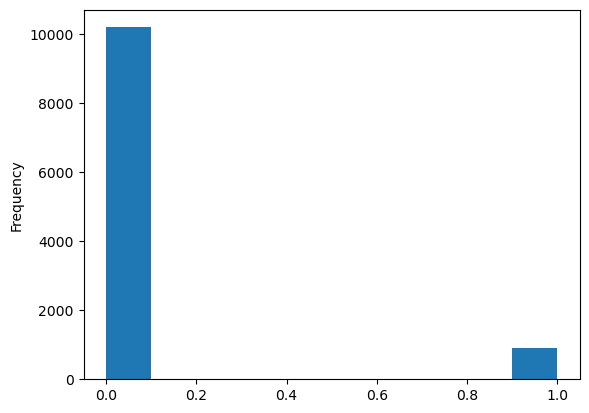

In [9]:
print(train["target"].value_counts())
train["target"].plot.hist()

## Events

In [10]:
events = pd.read_csv("./data/clean_events.csv", )
events.head(5)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


<Axes: >

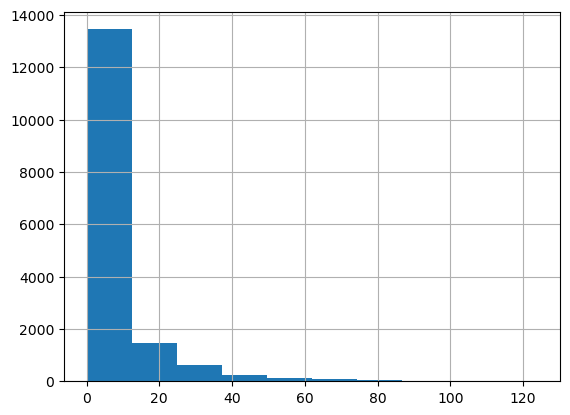

In [11]:
cookie_user_agents = (
    events.groupby("cookie_id")["pointer_y"]
      .nunique()
      .reset_index(name="n_user_agents")
      .sort_values("n_user_agents", ascending=False)
)

cookie_user_agents["n_user_agents"].hist()

In [12]:
events.describe()

,eid,item_id,search_page,pointer_x,pointer_y
count,288126.000000,1.926670e+05,89798.000000,95650.000000,95650.000000
mean,195.485645,1.029971e+06,2.896635,925.989472,537.526681
std,89.197681,1.729659e+04,2.861812,543.355723,305.515321
min,100.000000,1.000000e+06,1.000000,0.000000,0.000000
25%,100.000000,1.014931e+06,1.000000,462.000000,280.000000
50%,200.000000,1.029993e+06,2.000000,902.000000,536.000000
75%,210.000000,1.044945e+06,4.000000,1384.000000,795.000000
max,500.000000,1.059999e+06,63.000000,1920.000000,1080.000000


In [13]:
events.head(5)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


Анилиз типов ивентов

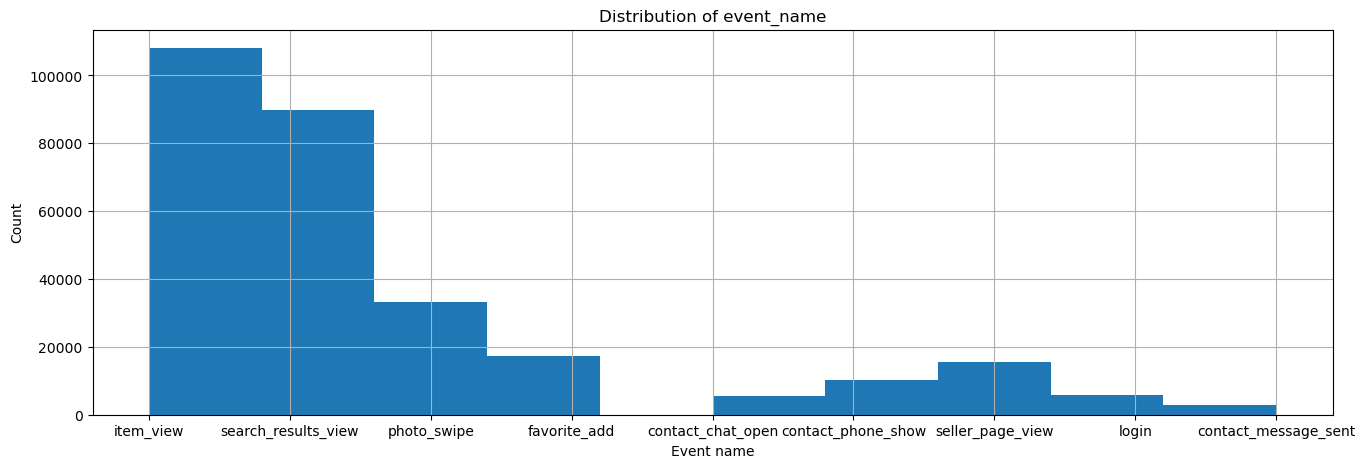

In [14]:
plt.figure(figsize=(16, 5))

events["event_name"].hist()

plt.xlabel("Event name")
plt.ylabel("Count")
plt.title("Distribution of event_name")

plt.show()

Nan в признаках

In [15]:
nan_ratio = (
    events.isna()
    .mean()
    .mul(100)
    .round(3)
    .sort_values(ascending=False)
)

nan_ratio

search_query     68.834
search_page      68.834
pointer_x        66.803
pointer_y        66.803
seller_type      39.142
item_id          33.131
item_category     7.804
item_location     4.963
cookie_id         0.000
event_ts          0.000
eid               0.000
event_name        0.000
platform          0.000
user_agent        0.000
dtype: float64

# Feature Engineering

## Разница во времени между ивентами

Гипотеза. Разница во времени между событиями может отличаться у ботов и людей. Добавлены признаки: средняя, медианная, максимальная и минимальная разница во времени между событиями, энтропия временных интервалов, наличие нулевой разницы между двумя событиями после округления до трёх знаков и количество таких нулевых интервалов.

In [16]:
events["event_ts"] = pd.to_datetime(events["event_ts"])

tmp = (
    events[["cookie_id", "event_ts"]]
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)

# Разница между соседними событиями
tmp["event_diff_sec"] = (
    tmp.groupby("cookie_id")["event_ts"]
    .diff()
    .dt.total_seconds()
)

# Округление до 3 знаков
tmp["event_diff_sec_rounded"] = tmp["event_diff_sec"].round(3)

# Shannon entropy
def entropy(x):
    probabilities = x.dropna().value_counts(normalize=True)

    if len(probabilities) == 0:
        return np.nan

    return -(probabilities * np.log2(probabilities)).sum()

# Статистики временных интервалов
event_diff_features = (
    tmp.groupby("cookie_id", as_index=False)
    .agg(
        mean_event_diff_sec=("event_diff_sec", "mean"),
        median_event_diff_sec=("event_diff_sec", "median"),
        min_event_diff_sec=("event_diff_sec", "min"),
        max_event_diff_sec=("event_diff_sec", "max"),
        event_diff_entropy=("event_diff_sec_rounded", entropy),
        has_zero_event_diff=("event_diff_sec_rounded", lambda x: (x == 0).any()),
        zero_event_diff_count=("event_diff_sec_rounded", lambda x: (x == 0).sum()),
    )
)

diff_features = [
    "mean_event_diff_sec",
    "median_event_diff_sec",
    "min_event_diff_sec",
    "max_event_diff_sec",
    "event_diff_entropy",
]

event_diff_features[diff_features] = (
    event_diff_features[diff_features]
    .round(3)
)

event_diff_features["has_zero_event_diff"] = (
    event_diff_features["has_zero_event_diff"]
    .astype(int)
)

event_diff_features["zero_event_diff_count"] = (
    event_diff_features["zero_event_diff_count"]
    .astype(int)
)

# Добавляем признаки и в train, и в test
train = train.merge(
    event_diff_features,
    on="cookie_id",
    how="left"
)

test = test.merge(
    event_diff_features,
    on="cookie_id",
    how="left"
)

print(train.shape)
print(test.shape)

train.head(3)

(11091, 10)
(4909, 9)


,cookie_id,cookie_created_at,target,mean_event_diff_sec,median_event_diff_sec,min_event_diff_sec,max_event_diff_sec,event_diff_entropy,has_zero_event_diff,zero_event_diff_count
0,ck_491599e6793133cb,2025-01-22 17:09:47,0,657.778,85.0,12.0,3782.0,3.170,0,0
1,ck_d6e0cd93b8d1565c,2025-01-28 06:44:42,0,1443.368,39.0,6.0,8571.0,4.143,0,0
2,ck_ef82f1d352ec7b10,2025-01-30 21:35:39,0,592.727,55.0,10.0,6697.0,4.681,0,0


mean_event_diff_sec      2.227031
median_event_diff_sec    2.227031
min_event_diff_sec       2.227031
max_event_diff_sec       2.227031
dtype: float64


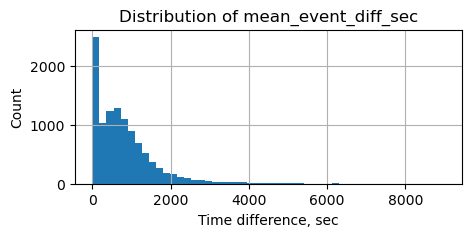

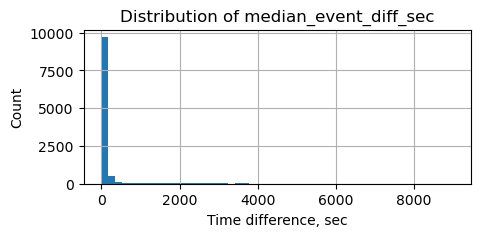

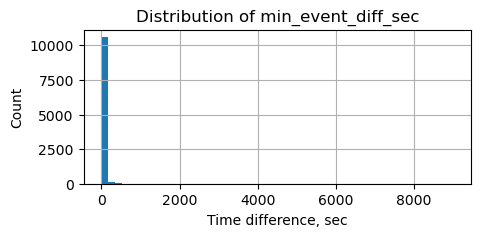

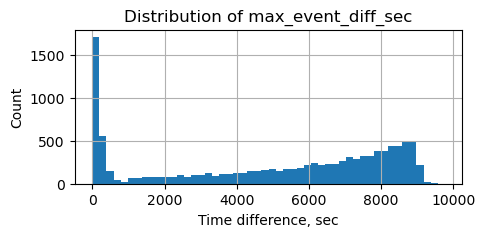

In [17]:
features = [
    "mean_event_diff_sec",
    "median_event_diff_sec",
    "min_event_diff_sec",
    "max_event_diff_sec"
]

print(
    train[features]
    .isna()
    .mean()
    .mul(100)
)

for feature in features:
    plt.figure(figsize=(5, 2))

    train[feature].hist(
        bins=50
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel("Time difference, sec")
    plt.ylabel("Count")
    plt.show()

Много выбросов. Возможно стоит их удалить

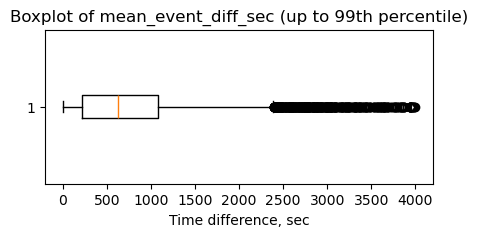

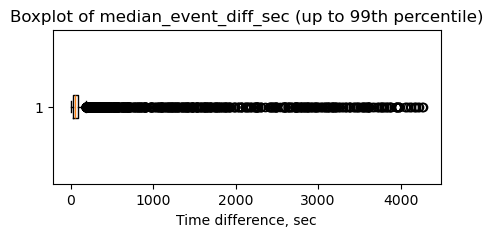

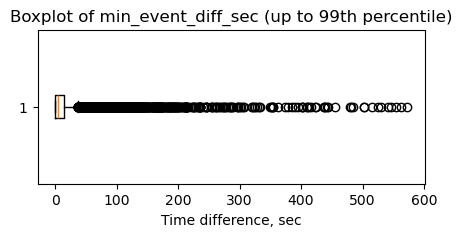

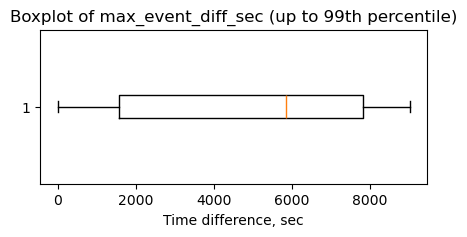

In [18]:
for feature in features:
    upper = train[feature].quantile(0.99)

    plt.figure(figsize=(5, 2))

    plt.boxplot(
        train.loc[train[feature] <= upper, feature].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {feature} (up to 99th percentile)")
    plt.xlabel("Time difference, sec")
    plt.show()

## Сoncurrent ratio

Гипотеза. Возможно боты слишком быстро совершают действия

Эти признаки - соотношение пар событый с нулевым временной разницей ко всем событиям 

In [19]:
events["event_ts"] = pd.to_datetime(events["event_ts"])

events = (
    events
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)

events["lag_sec"] = (
    events
    .groupby("cookie_id")["event_ts"]
    .diff()
    .dt.total_seconds()
)

events["is_concurrent"] = (
    events["lag_sec"] == 0
).astype(int)

concurrent_features = (
    events
    .groupby("cookie_id")
    .agg(
        concurrent_count=("is_concurrent", "sum"),
        n_intervals=("lag_sec", "count"),
        min_lag_sec=("lag_sec", "min"),
        median_lag_sec=("lag_sec", "median"),
        mean_lag_sec=("lag_sec", "mean"),
        std_lag_sec=("lag_sec", "std")
    )
    .reset_index()
)

concurrent_features["concurrent_ratio"] = (
    concurrent_features["concurrent_count"]
    / concurrent_features["n_intervals"].replace(0, np.nan)
)

# Добавляем признаки и в train, и в test
train = train.merge(
    concurrent_features,
    on="cookie_id",
    how="left"
)

test = test.merge(
    concurrent_features,
    on="cookie_id",
    how="left"
)

fill_cols = [
    "concurrent_count",
    "n_intervals",
    "concurrent_ratio"
]

train[fill_cols] = train[fill_cols].fillna(0)
test[fill_cols] = test[fill_cols].fillna(0)

print(train.shape)
print(test.shape)

train[
    [
        "cookie_id",
        "concurrent_count",
        "n_intervals",
        "concurrent_ratio",
        "min_lag_sec",
        "median_lag_sec",
        "mean_lag_sec",
        "std_lag_sec"
    ]
].head()

(11091, 17)
(4909, 16)


,cookie_id,concurrent_count,n_intervals,concurrent_ratio,min_lag_sec,median_lag_sec,mean_lag_sec,std_lag_sec
0,ck_491599e6793133cb,0,9,0.000000,12.0,85.0,657.777778,1287.481046
1,ck_d6e0cd93b8d1565c,0,19,0.000000,6.0,39.0,1443.368421,2720.405897
2,ck_ef82f1d352ec7b10,0,33,0.000000,10.0,55.0,592.727273,1681.718769
3,ck_25b31db8c46573f0,1,18,0.055556,0.0,60.0,576.055556,1702.891467
4,ck_8e5c58cd8631e6dc,0,10,0.000000,5.0,53.0,836.500000,2487.593806


## Новый признак. Количество зафиксированных кликов

Количество кликов по дням - mean, max, min и mode

Количество кликов в минуту - mean, max, min и mode

В это признаке слишком мало выбросов и много nan events. Возможно неинформативный признак.

По дням

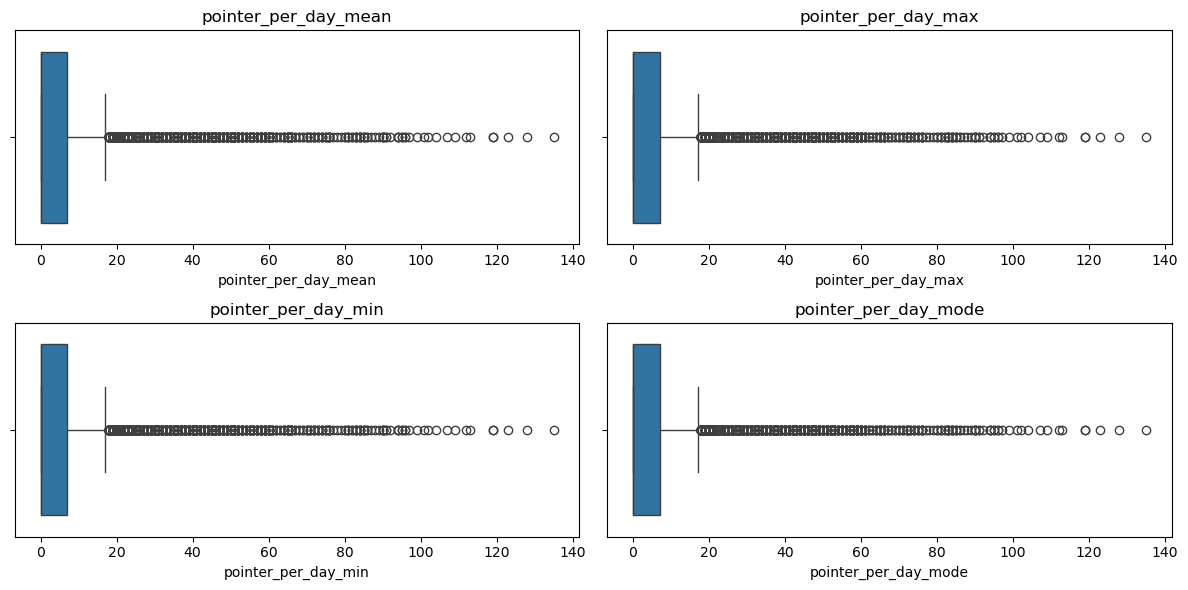

(11091, 21)
(4909, 20)
       pointer_per_day_mean  pointer_per_day_max  pointer_per_day_min  \
count          11091.000000         11091.000000         11091.000000   
mean               5.972681             5.972681             5.972681   
std               12.651672            12.651672            12.651672   
min                0.000000             0.000000             0.000000   
25%                0.000000             0.000000             0.000000   
50%                0.000000             0.000000             0.000000   
75%                7.000000             7.000000             7.000000   
max              135.000000           135.000000           135.000000   

       pointer_per_day_mode  
count          11091.000000  
mean               5.972681  
std               12.651672  
min                0.000000  
25%                0.000000  
50%                0.000000  
75%                7.000000  
max              135.000000  


,pointer_per_day_mean,pointer_per_day_max,pointer_per_day_min,pointer_per_day_mode
0,9.0,9,9,9
1,20.0,20,20,20
2,33.0,33,33,33
3,0.0,0,0,0
4,0.0,0,0,0


In [20]:
events["event_ts"] = pd.to_datetime(events["event_ts"])
events["event_date"] = events["event_ts"].dt.date

events["is_click"] = (
    events["pointer_x"].notna() &
    events["pointer_y"].notna()
).astype(int)

clicks_per_day = (
    events.groupby(["cookie_id", "event_date"])["is_click"]
    .sum()
    .reset_index(name="clicks_per_day")
)

click_stats = (
    clicks_per_day.groupby("cookie_id")["clicks_per_day"]
    .agg(
        pointer_per_day_mean="mean",
        pointer_per_day_max="max",
        pointer_per_day_min="min",
        pointer_per_day_mode=lambda x: x.mode().iloc[0]
    )
    .reset_index()
)

train = train.merge(click_stats, on="cookie_id", how="left")
test = test.merge(click_stats, on="cookie_id", how="left")

cols = [
    "pointer_per_day_mean",
    "pointer_per_day_max",
    "pointer_per_day_min",
    "pointer_per_day_mode"
]

train[cols] = train[cols].fillna(0)
test[cols] = test[cols].fillna(0)

# Plots только для train
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for ax, feature in zip(axes, cols):
    sns.boxplot(x=train[feature], ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

print(train.shape)
print(test.shape)

print(train[cols].describe())
train[cols].head()

По минутам

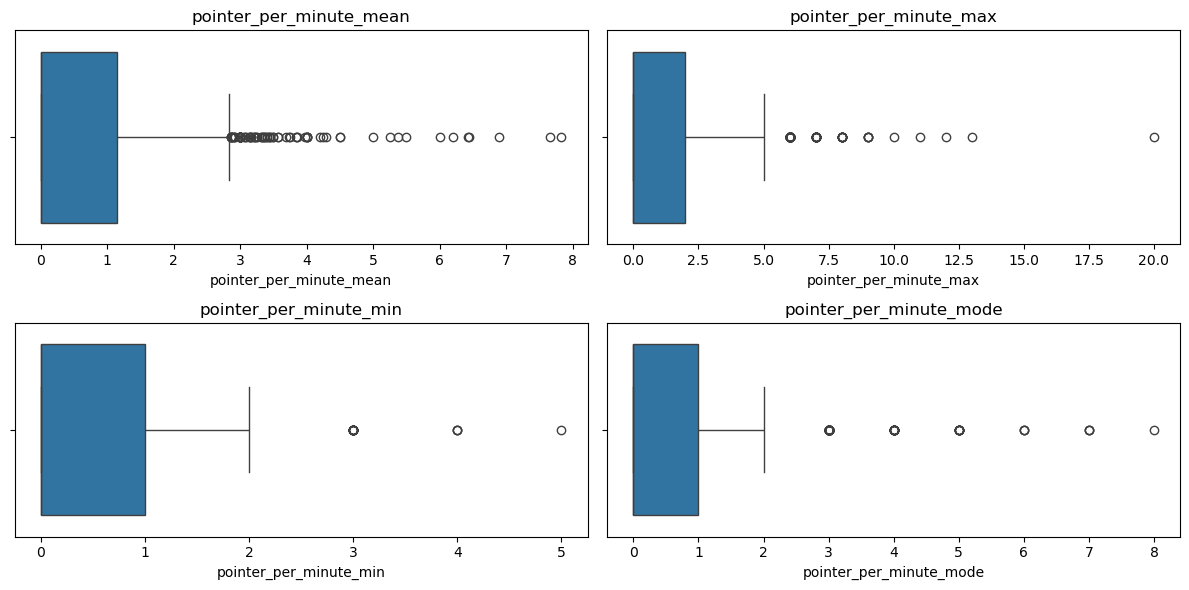

(11091, 25)
(4909, 24)
       pointer_per_minute_mean  pointer_per_minute_max  \
count             11091.000000            11091.000000   
mean                  0.511062                0.922640   
std                   0.745191                1.441108   
min                   0.000000                0.000000   
25%                   0.000000                0.000000   
50%                   0.000000                0.000000   
75%                   1.142857                2.000000   
max                   7.833333               20.000000   

       pointer_per_minute_min  pointer_per_minute_mode  
count            11091.000000             11091.000000  
mean                 0.268957                 0.410152  
std                  0.476376                 0.622628  
min                  0.000000                 0.000000  
25%                  0.000000                 0.000000  
50%                  0.000000                 0.000000  
75%                  1.000000                 1.000000 

,pointer_per_minute_mean,pointer_per_minute_max,pointer_per_minute_min,pointer_per_minute_mode
0,1.125000,2,0,1
1,1.538462,3,1,1
2,1.269231,2,1,1
3,0.000000,0,0,0
4,0.000000,0,0,0


In [21]:
events["event_ts"] = pd.to_datetime(events["event_ts"])
events["event_minute"] = events["event_ts"].dt.floor("min")

events["is_click"] = (
    events["pointer_x"].notna() &
    events["pointer_y"].notna()
).astype(int)

clicks_per_minute = (
    events.groupby(["cookie_id", "event_minute"])["is_click"]
    .sum()
    .reset_index(name="clicks_per_minute")
)

click_minute_stats = (
    clicks_per_minute.groupby("cookie_id")["clicks_per_minute"]
    .agg(
        pointer_per_minute_mean="mean",
        pointer_per_minute_max="max",
        pointer_per_minute_min="min",
        pointer_per_minute_mode=lambda x: x.mode().iloc[0]
    )
    .reset_index()
)

train = train.merge(click_minute_stats, on="cookie_id", how="left")
test = test.merge(click_minute_stats, on="cookie_id", how="left")

cols = [
    "pointer_per_minute_mean",
    "pointer_per_minute_max",
    "pointer_per_minute_min",
    "pointer_per_minute_mode"
]

train[cols] = train[cols].fillna(0)
test[cols] = test[cols].fillna(0)

# Plots только для train
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for ax, feature in zip(axes, cols):
    sns.boxplot(x=train[feature], ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

print(train.shape)
print(test.shape)

# Info
print(train[cols].describe())
train[cols].head()

## Признак - количество разных event_name ивентов у cookie id

Гипотеза: боты, скорее всего, выполняют массово определенный набор ивентов.  Например, могут быстро и многократно просматривать или скачивать объявленияю

In [22]:
event_name_counts = (
    events.groupby(["cookie_id", "event_name"])
    .size()
    .unstack(fill_value=0)
    .add_prefix("event_name_count_")
    .reset_index()
)

train = train.merge(
    event_name_counts,
    on="cookie_id",
    how="left"
)

test = test.merge(
    event_name_counts,
    on="cookie_id",
    how="left"
)

event_cols = [
    col for col in event_name_counts.columns
    if col.startswith("event_name_count_")
]

train[event_cols] = (
    train[event_cols]
    .fillna(0)
    .astype(int)
)

test[event_cols] = (
    test[event_cols]
    .fillna(0)
    .astype(int)
)

print(train.shape)
print(test.shape)

train.head(3)

(11091, 34)
(4909, 33)


,cookie_id,cookie_created_at,target,mean_event_diff_sec,median_event_diff_sec,min_event_diff_sec,max_event_diff_sec,event_diff_entropy,has_zero_event_diff,zero_event_diff_count,concurrent_count,n_intervals,min_lag_sec,median_lag_sec,mean_lag_sec,std_lag_sec,concurrent_ratio,pointer_per_day_mean,pointer_per_day_max,pointer_per_day_min,pointer_per_day_mode,pointer_per_minute_mean,pointer_per_minute_max,pointer_per_minute_min,pointer_per_minute_mode,event_name_count_contact_chat_open,event_name_count_contact_message_sent,event_name_count_contact_phone_show,event_name_count_favorite_add,event_name_count_item_view,event_name_count_login,event_name_count_photo_swipe,event_name_count_search_results_view,event_name_count_seller_page_view
0,ck_491599e6793133cb,2025-01-22 17:09:47,0,657.778,85.0,12.0,3782.0,3.170,0,0,0,9,12.0,85.0,657.777778,1287.481046,0.0,9.0,9,9,9,1.125000,2,0,1,0,0,0,1,4,0,3,2,0
1,ck_d6e0cd93b8d1565c,2025-01-28 06:44:42,0,1443.368,39.0,6.0,8571.0,4.143,0,0,0,19,6.0,39.0,1443.368421,2720.405897,0.0,20.0,20,20,20,1.538462,3,1,1,0,0,1,2,1,0,8,8,0
2,ck_ef82f1d352ec7b10,2025-01-30 21:35:39,0,592.727,55.0,10.0,6697.0,4.681,0,0,0,33,10.0,55.0,592.727273,1681.718769,0.0,33.0,33,33,33,1.269231,2,1,1,1,1,1,0,13,2,2,13,1


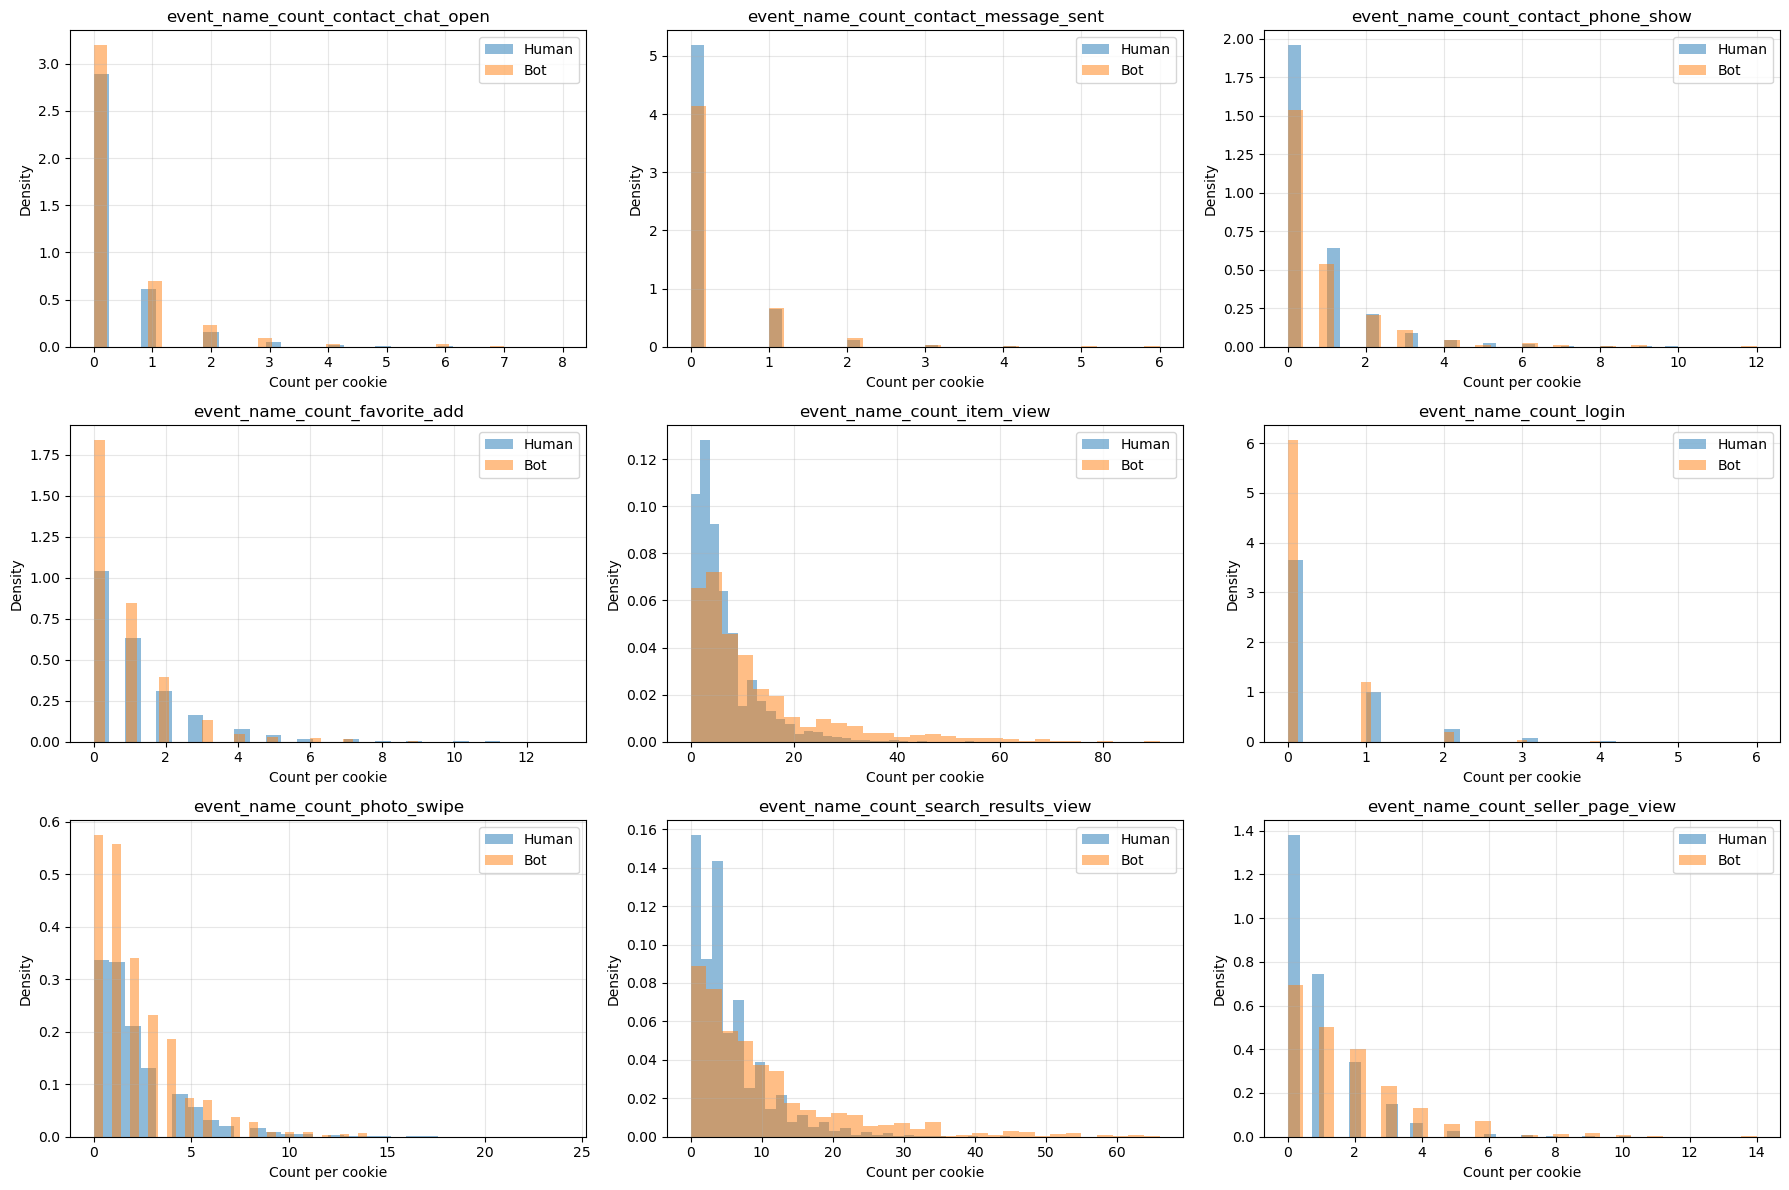

In [23]:
n_cols = 3
n_rows = int(np.ceil(len(event_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, event_cols):

    ax.hist(
        train.loc[train["target"] == 0, col],
        bins=30,
        alpha=0.5,
        label="Human",
        density=True
    )

    ax.hist(
        train.loc[train["target"] == 1, col],
        bins=30,
        alpha=0.5,
        label="Bot",
        density=True
    )

    ax.set_title(col)
    ax.set_xlabel("Count per cookie")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.3)

for ax in axes[len(event_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

## Признак - сколько разных пар событий.

Гипотеза. По последовательности соседних событий пользователя можно определить паттерны поведения бота. У бота может быть много повторяющихся сценариев и переходов между одними и теми же событиями.

Например: contact_chat_open → item_view.

In [24]:
events["event_ts"] = pd.to_datetime(events["event_ts"])

events = (
    events
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)

events["next_event_name"] = (
    events
    .groupby("cookie_id")["event_name"]
    .shift(-1)
)

event_pairs = (
    events
    .dropna(subset=["next_event_name"])
    .copy()
)

event_pairs["event_pair"] = (
    event_pairs["event_name"].astype(str)
    + "__to__"
    + event_pairs["next_event_name"].astype(str)
)

event_pair_counts = (
    event_pairs
    .groupby(["cookie_id", "event_pair"])
    .size()
    .unstack(fill_value=0)
    .add_prefix("event_pair_count_")
    .reset_index()
)

# Добавляем и в train, и в test
train = train.merge(
    event_pair_counts,
    on="cookie_id",
    how="left"
)

test = test.merge(
    event_pair_counts,
    on="cookie_id",
    how="left"
)

event_pair_cols = [
    col
    for col in event_pair_counts.columns
    if col.startswith("event_pair_count_")
]

train[event_pair_cols] = (
    train[event_pair_cols]
    .fillna(0)
    .astype(int)
)

test[event_pair_cols] = (
    test[event_pair_cols]
    .fillna(0)
    .astype(int)
)

print(train.shape)
print(test.shape)

train[
    ["cookie_id"] + event_pair_cols
].head()

(11091, 115)
(4909, 114)


,cookie_id,event_pair_count_contact_chat_open__to__contact_chat_open,event_pair_count_contact_chat_open__to__contact_message_sent,event_pair_count_contact_chat_open__to__contact_phone_show,event_pair_count_contact_chat_open__to__favorite_add,event_pair_count_contact_chat_open__to__item_view,event_pair_count_contact_chat_open__to__login,event_pair_count_contact_chat_open__to__photo_swipe,event_pair_count_contact_chat_open__to__search_results_view,event_pair_count_contact_chat_open__to__seller_page_view,event_pair_count_contact_message_sent__to__contact_chat_open,event_pair_count_contact_message_sent__to__contact_message_sent,event_pair_count_contact_message_sent__to__contact_phone_show,event_pair_count_contact_message_sent__to__favorite_add,event_pair_count_contact_message_sent__to__item_view,event_pair_count_contact_message_sent__to__login,event_pair_count_contact_message_sent__to__photo_swipe,event_pair_count_contact_message_sent__to__search_results_view,event_pair_count_contact_message_sent__to__seller_page_view,event_pair_count_contact_phone_show__to__contact_chat_open,event_pair_count_contact_phone_show__to__contact_message_sent,event_pair_count_contact_phone_show__to__contact_phone_show,event_pair_count_contact_phone_show__to__favorite_add,event_pair_count_contact_phone_show__to__item_view,event_pair_count_contact_phone_show__to__login,event_pair_count_contact_phone_show__to__photo_swipe,event_pair_count_contact_phone_show__to__search_results_view,event_pair_count_contact_phone_show__to__seller_page_view,event_pair_count_favorite_add__to__contact_chat_open,event_pair_count_favorite_add__to__contact_message_sent,event_pair_count_favorite_add__to__contact_phone_show,event_pair_count_favorite_add__to__favorite_add,event_pair_count_favorite_add__to__item_view,event_pair_count_favorite_add__to__login,event_pair_count_favorite_add__to__photo_swipe,event_pair_count_favorite_add__to__search_results_view,event_pair_count_favorite_add__to__seller_page_view,event_pair_count_item_view__to__contact_chat_open,event_pair_count_item_view__to__contact_message_sent,event_pair_count_item_view__to__contact_phone_show,event_pair_count_item_view__to__favorite_add,event_pair_count_item_view__to__item_view,event_pair_count_item_view__to__login,event_pair_count_item_view__to__photo_swipe,event_pair_count_item_view__to__search_results_view,event_pair_count_item_view__to__seller_page_view,event_pair_count_login__to__contact_chat_open,event_pair_count_login__to__contact_message_sent,event_pair_count_login__to__contact_phone_show,event_pair_count_login__to__favorite_add,event_pair_count_login__to__item_view,event_pair_count_login__to__login,event_pair_count_login__to__photo_swipe,event_pair_count_login__to__search_results_view,event_pair_count_login__to__seller_page_view,event_pair_count_photo_swipe__to__contact_chat_open,event_pair_count_photo_swipe__to__contact_message_sent,event_pair_count_photo_swipe__to__contact_phone_show,event_pair_count_photo_swipe__to__favorite_add,event_pair_count_photo_swipe__to__item_view,event_pair_count_photo_swipe__to__login,event_pair_count_photo_swipe__to__photo_swipe,event_pair_count_photo_swipe__to__search_results_view,event_pair_count_photo_swipe__to__seller_page_view,event_pair_count_search_results_view__to__contact_chat_open,event_pair_count_search_results_view__to__contact_message_sent,event_pair_count_search_results_view__to__contact_phone_show,event_pair_count_search_results_view__to__favorite_add,event_pair_count_search_results_view__to__item_view,event_pair_count_search_results_view__to__login,event_pair_count_search_results_view__to__photo_swipe,event_pair_count_search_results_view__to__search_results_view,event_pair_count_search_results_view__to__seller_page_view,event_pair_count_seller_page_view__to__contact_chat_open,event_pair_count_seller_page_view__to__contact_message_sent,event_pair_count_seller_page_view__to__contact_phone_show,event_pair_count_seller_page_view__to__favorite_add,event_pair_count_se

## Количество уникальных категорий в категориальных признаках и mod этих категорий
 

Гипотеза. Возможно, у ботов менее разнообразные действия, чем у обычных пользователей.

(11091, 129)
(4909, 128)


,cookie_id,cookie_created_at,target,mean_event_diff_sec,median_event_diff_sec,min_event_diff_sec,max_event_diff_sec,event_diff_entropy,has_zero_event_diff,zero_event_diff_count,concurrent_count,n_intervals,min_lag_sec,median_lag_sec,mean_lag_sec,std_lag_sec,concurrent_ratio,pointer_per_day_mean,pointer_per_day_max,pointer_per_day_min,pointer_per_day_mode,pointer_per_minute_mean,pointer_per_minute_max,pointer_per_minute_min,pointer_per_minute_mode,event_name_count_contact_chat_open,event_name_count_contact_message_sent,event_name_count_contact_phone_show,event_name_count_favorite_add,event_name_count_item_view,event_name_count_login,event_name_count_photo_swipe,event_name_count_search_results_view,event_name_count_seller_page_view,event_pair_count_contact_chat_open__to__contact_chat_open,event_pair_count_contact_chat_open__to__contact_message_sent,event_pair_count_contact_chat_open__to__contact_phone_show,event_pair_count_contact_chat_open__to__favorite_add,event_pair_count_contact_chat_open__to__item_view,event_pair_count_contact_chat_open__to__login,event_pair_count_contact_chat_open__to__photo_swipe,event_pair_count_contact_chat_open__to__search_results_view,event_pair_count_contact_chat_open__to__seller_page_view,event_pair_count_contact_message_sent__to__contact_chat_open,event_pair_count_contact_message_sent__to__contact_message_sent,event_pair_count_contact_message_sent__to__contact_phone_show,event_pair_count_contact_message_sent__to__favorite_add,event_pair_count_contact_message_sent__to__item_view,event_pair_count_contact_message_sent__to__login,event_pair_count_contact_message_sent__to__photo_swipe,event_pair_count_contact_message_sent__to__search_results_view,event_pair_count_contact_message_sent__to__seller_page_view,event_pair_count_contact_phone_show__to__contact_chat_open,event_pair_count_contact_phone_show__to__contact_message_sent,event_pair_count_contact_phone_show__to__contact_phone_show,event_pair_count_contact_phone_show__to__favorite_add,event_pair_count_contact_phone_show__to__item_view,event_pair_count_contact_phone_show__to__login,event_pair_count_contact_phone_show__to__photo_swipe,event_pair_count_contact_phone_show__to__search_results_view,event_pair_count_contact_phone_show__to__seller_page_view,event_pair_count_favorite_add__to__contact_chat_open,event_pair_count_favorite_add__to__contact_message_sent,event_pair_count_favorite_add__to__contact_phone_show,event_pair_count_favorite_add__to__favorite_add,event_pair_count_favorite_add__to__item_view,event_pair_count_favorite_add__to__login,event_pair_count_favorite_add__to__photo_swipe,event_pair_count_favorite_add__to__search_results_view,event_pair_count_favorite_add__to__seller_page_view,event_pair_count_item_view__to__contact_chat_open,event_pair_count_item_view__to__contact_message_sent,event_pair_count_item_view__to__contact_phone_show,event_pair_count_item_view__to__favorite_add,event_pair_count_item_view__to__item_view,event_pair_count_item_view__to__login,event_pair_count_item_view__to__photo_swipe,event_pair_count_item_view__to__search_results_view,event_pair_count_item_view__to__seller_page_view,event_pair_count_login__to__contact_chat_open,event_pair_count_login__to__contact_message_sent,event_pair_count_login__to__contact_phone_show,event_pair_count_login__to__favorite_add,event_pair_count_login__to__item_view,event_pair_count_login__to__login,event_pair_count_login__to__photo_swipe,event_pair_count_login__to__search_results_view,event_pair_count_login__to__seller_page_view,event_pair_count_photo_swipe__to__contact_chat_open,event_pair_count_photo_swipe__to__contact_message_sent,event_pair_count_photo_swipe__to__contact_phone_show,event_pair_count_photo_swipe__to__favorite_add,event_pair_count_photo_swipe__to__item_view,event_pair_count_photo_swipe__to__login,event_pair_count_photo_swipe__to__photo_swipe,event_pair_count_photo_swipe__to__search_results_view,event_pair_count_photo_swipe__to__seller_page_view,event_pair_count_search_results

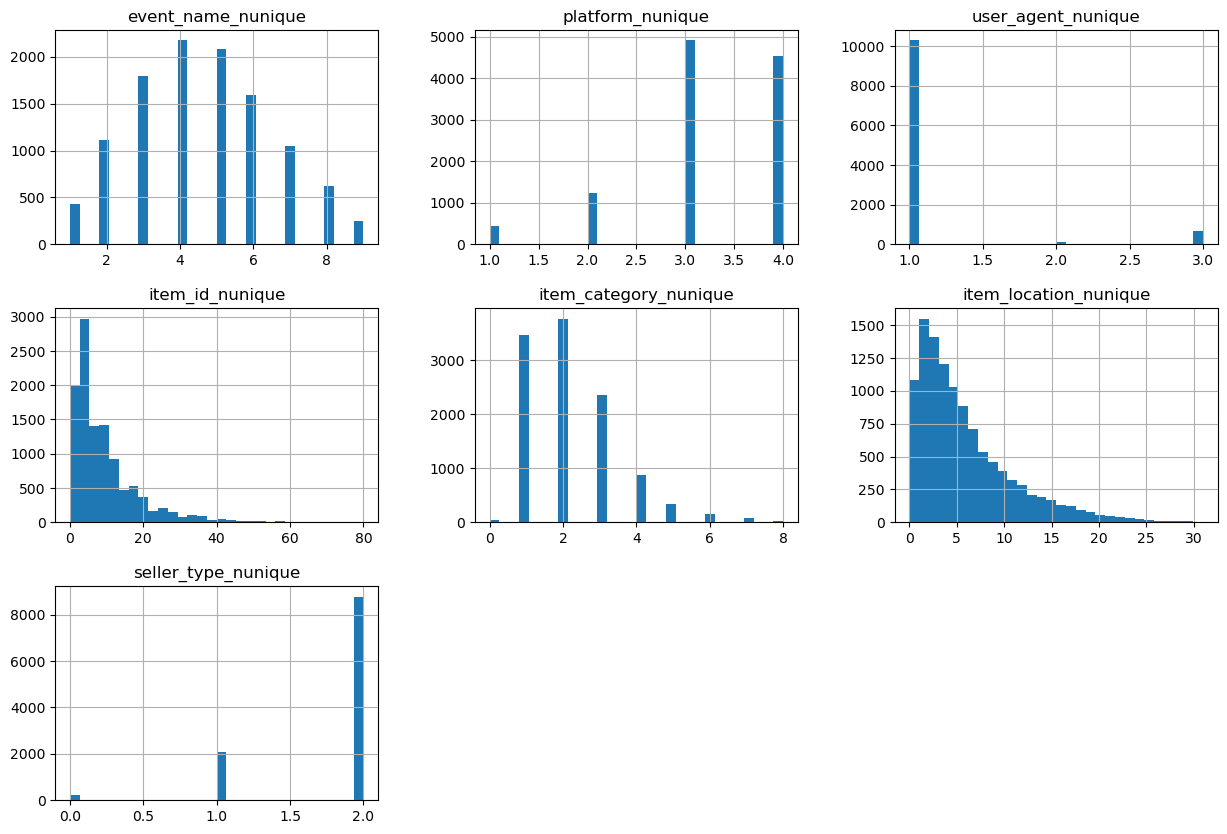

In [25]:
cols = [
    "event_name",
    "platform",
    "user_agent",
    "item_id",
    "item_category",
    "item_location",
    "seller_type",
]

def get_mode(x):
    mode = x.dropna().mode()
    return mode.iloc[0] if len(mode) > 0 else np.nan


for col in cols:
    counts = events.groupby("cookie_id")[col].nunique()
    modes = events.groupby("cookie_id")[col].apply(get_mode)

    # Количество уникальных значений
    train[f"{col}_nunique"] = (
        train["cookie_id"]
        .map(counts)
        .fillna(0)
        .astype(int)
    )

    test[f"{col}_nunique"] = (
        test["cookie_id"]
        .map(counts)
        .fillna(0)
        .astype(int)
    )

    # Mode
    train_mode = train["cookie_id"].map(modes).fillna("unknown")
    test_mode = test["cookie_id"].map(modes).fillna("unknown")

    # Единая кодировка категорий
    all_modes = pd.concat([train_mode, test_mode], ignore_index=True)
    _, uniques = pd.factorize(all_modes)

    mapping = {
        value: i
        for i, value in enumerate(uniques)
    }

    train[f"{col}_mode"] = train_mode.map(mapping).astype(int)
    test[f"{col}_mode"] = test_mode.map(mapping).astype(int)


nunique_cols = [f"{col}_nunique" for col in cols]
mode_cols = [f"{col}_mode" for col in cols]

train[nunique_cols].hist(
    bins=30,
    figsize=(15, 10)
)

print(train.shape)
print(test.shape)

train.head(3)

## Количество search_query и количество уникальных search_query

Гипотеза. Может у ботов было мало поисков или там одинаковый текст.

In [26]:
search_features = (
    events.groupby("cookie_id")["search_query"]
    .agg(
        search_query_count="count",
        search_query_nunique="nunique"
    )
    .reset_index()
)

train = train.merge(
    search_features,
    on="cookie_id",
    how="left"
)

test = test.merge(
    search_features,
    on="cookie_id",
    how="left"
)

search_cols = [
    "search_query_count",
    "search_query_nunique"
]

train[search_cols] = (
    train[search_cols]
    .fillna(0)
    .astype(int)
)

test[search_cols] = (
    test[search_cols]
    .fillna(0)
    .astype(int)
)
print(train.shape)
print(test.shape)

train.head(3)

(11091, 131)
(4909, 130)


,cookie_id,cookie_created_at,target,mean_event_diff_sec,median_event_diff_sec,min_event_diff_sec,max_event_diff_sec,event_diff_entropy,has_zero_event_diff,zero_event_diff_count,concurrent_count,n_intervals,min_lag_sec,median_lag_sec,mean_lag_sec,std_lag_sec,concurrent_ratio,pointer_per_day_mean,pointer_per_day_max,pointer_per_day_min,pointer_per_day_mode,pointer_per_minute_mean,pointer_per_minute_max,pointer_per_minute_min,pointer_per_minute_mode,event_name_count_contact_chat_open,event_name_count_contact_message_sent,event_name_count_contact_phone_show,event_name_count_favorite_add,event_name_count_item_view,event_name_count_login,event_name_count_photo_swipe,event_name_count_search_results_view,event_name_count_seller_page_view,event_pair_count_contact_chat_open__to__contact_chat_open,event_pair_count_contact_chat_open__to__contact_message_sent,event_pair_count_contact_chat_open__to__contact_phone_show,event_pair_count_contact_chat_open__to__favorite_add,event_pair_count_contact_chat_open__to__item_view,event_pair_count_contact_chat_open__to__login,event_pair_count_contact_chat_open__to__photo_swipe,event_pair_count_contact_chat_open__to__search_results_view,event_pair_count_contact_chat_open__to__seller_page_view,event_pair_count_contact_message_sent__to__contact_chat_open,event_pair_count_contact_message_sent__to__contact_message_sent,event_pair_count_contact_message_sent__to__contact_phone_show,event_pair_count_contact_message_sent__to__favorite_add,event_pair_count_contact_message_sent__to__item_view,event_pair_count_contact_message_sent__to__login,event_pair_count_contact_message_sent__to__photo_swipe,event_pair_count_contact_message_sent__to__search_results_view,event_pair_count_contact_message_sent__to__seller_page_view,event_pair_count_contact_phone_show__to__contact_chat_open,event_pair_count_contact_phone_show__to__contact_message_sent,event_pair_count_contact_phone_show__to__contact_phone_show,event_pair_count_contact_phone_show__to__favorite_add,event_pair_count_contact_phone_show__to__item_view,event_pair_count_contact_phone_show__to__login,event_pair_count_contact_phone_show__to__photo_swipe,event_pair_count_contact_phone_show__to__search_results_view,event_pair_count_contact_phone_show__to__seller_page_view,event_pair_count_favorite_add__to__contact_chat_open,event_pair_count_favorite_add__to__contact_message_sent,event_pair_count_favorite_add__to__contact_phone_show,event_pair_count_favorite_add__to__favorite_add,event_pair_count_favorite_add__to__item_view,event_pair_count_favorite_add__to__login,event_pair_count_favorite_add__to__photo_swipe,event_pair_count_favorite_add__to__search_results_view,event_pair_count_favorite_add__to__seller_page_view,event_pair_count_item_view__to__contact_chat_open,event_pair_count_item_view__to__contact_message_sent,event_pair_count_item_view__to__contact_phone_show,event_pair_count_item_view__to__favorite_add,event_pair_count_item_view__to__item_view,event_pair_count_item_view__to__login,event_pair_count_item_view__to__photo_swipe,event_pair_count_item_view__to__search_results_view,event_pair_count_item_view__to__seller_page_view,event_pair_count_login__to__contact_chat_open,event_pair_count_login__to__contact_message_sent,event_pair_count_login__to__contact_phone_show,event_pair_count_login__to__favorite_add,event_pair_count_login__to__item_view,event_pair_count_login__to__login,event_pair_count_login__to__photo_swipe,event_pair_count_login__to__search_results_view,event_pair_count_login__to__seller_page_view,event_pair_count_photo_swipe__to__contact_chat_open,event_pair_count_photo_swipe__to__contact_message_sent,event_pair_count_photo_swipe__to__contact_phone_show,event_pair_count_photo_swipe__to__favorite_add,event_pair_count_photo_swipe__to__item_view,event_pair_count_photo_swipe__to__login,event_pair_count_photo_swipe__to__photo_swipe,event_pair_count_photo_swipe__to__search_results_view,event_pair_count_photo_swipe__to__seller_page_view,event_pair_count_search_results

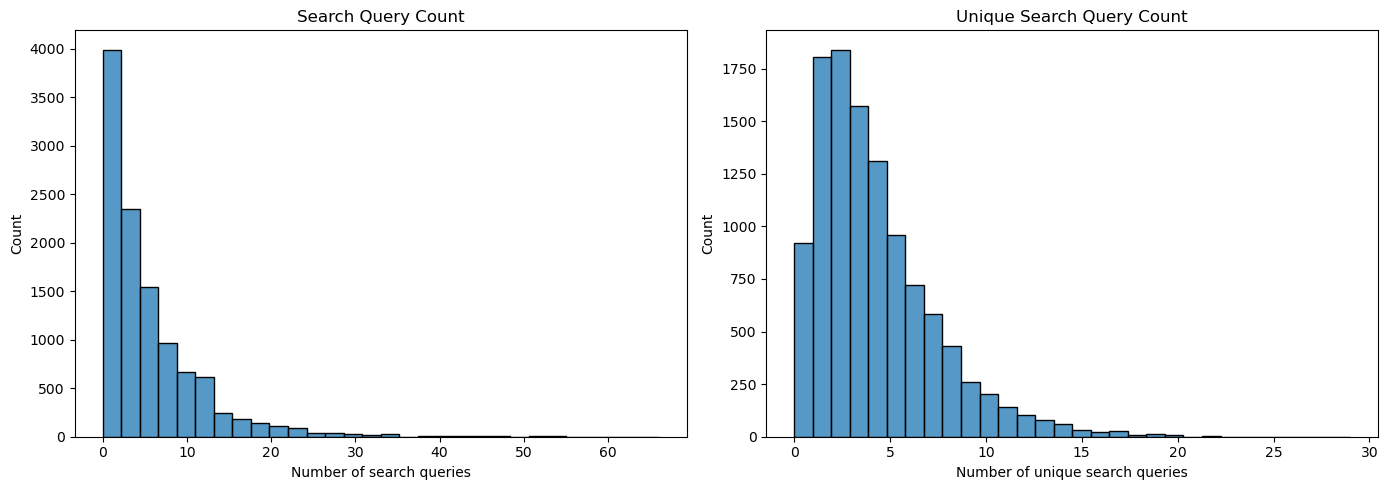

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=train,
    x="search_query_count",
    bins=30,
    ax=axes[0]
)

axes[0].set_title("Search Query Count")
axes[0].set_xlabel("Number of search queries")

sns.histplot(
    data=train,
    x="search_query_nunique",
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Unique Search Query Count")
axes[1].set_xlabel("Number of unique search queries")

plt.tight_layout()
plt.show()

## Энтропия категориальных признаков

Гипотеза. Возможно, у ботов менее разнообразные действия, чем у обычных пользователей.

(11091, 138)
(4909, 137)


,cookie_id,cookie_created_at,target,mean_event_diff_sec,median_event_diff_sec,min_event_diff_sec,max_event_diff_sec,event_diff_entropy,has_zero_event_diff,zero_event_diff_count,concurrent_count,n_intervals,min_lag_sec,median_lag_sec,mean_lag_sec,std_lag_sec,concurrent_ratio,pointer_per_day_mean,pointer_per_day_max,pointer_per_day_min,pointer_per_day_mode,pointer_per_minute_mean,pointer_per_minute_max,pointer_per_minute_min,pointer_per_minute_mode,event_name_count_contact_chat_open,event_name_count_contact_message_sent,event_name_count_contact_phone_show,event_name_count_favorite_add,event_name_count_item_view,event_name_count_login,event_name_count_photo_swipe,event_name_count_search_results_view,event_name_count_seller_page_view,event_pair_count_contact_chat_open__to__contact_chat_open,event_pair_count_contact_chat_open__to__contact_message_sent,event_pair_count_contact_chat_open__to__contact_phone_show,event_pair_count_contact_chat_open__to__favorite_add,event_pair_count_contact_chat_open__to__item_view,event_pair_count_contact_chat_open__to__login,event_pair_count_contact_chat_open__to__photo_swipe,event_pair_count_contact_chat_open__to__search_results_view,event_pair_count_contact_chat_open__to__seller_page_view,event_pair_count_contact_message_sent__to__contact_chat_open,event_pair_count_contact_message_sent__to__contact_message_sent,event_pair_count_contact_message_sent__to__contact_phone_show,event_pair_count_contact_message_sent__to__favorite_add,event_pair_count_contact_message_sent__to__item_view,event_pair_count_contact_message_sent__to__login,event_pair_count_contact_message_sent__to__photo_swipe,event_pair_count_contact_message_sent__to__search_results_view,event_pair_count_contact_message_sent__to__seller_page_view,event_pair_count_contact_phone_show__to__contact_chat_open,event_pair_count_contact_phone_show__to__contact_message_sent,event_pair_count_contact_phone_show__to__contact_phone_show,event_pair_count_contact_phone_show__to__favorite_add,event_pair_count_contact_phone_show__to__item_view,event_pair_count_contact_phone_show__to__login,event_pair_count_contact_phone_show__to__photo_swipe,event_pair_count_contact_phone_show__to__search_results_view,event_pair_count_contact_phone_show__to__seller_page_view,event_pair_count_favorite_add__to__contact_chat_open,event_pair_count_favorite_add__to__contact_message_sent,event_pair_count_favorite_add__to__contact_phone_show,event_pair_count_favorite_add__to__favorite_add,event_pair_count_favorite_add__to__item_view,event_pair_count_favorite_add__to__login,event_pair_count_favorite_add__to__photo_swipe,event_pair_count_favorite_add__to__search_results_view,event_pair_count_favorite_add__to__seller_page_view,event_pair_count_item_view__to__contact_chat_open,event_pair_count_item_view__to__contact_message_sent,event_pair_count_item_view__to__contact_phone_show,event_pair_count_item_view__to__favorite_add,event_pair_count_item_view__to__item_view,event_pair_count_item_view__to__login,event_pair_count_item_view__to__photo_swipe,event_pair_count_item_view__to__search_results_view,event_pair_count_item_view__to__seller_page_view,event_pair_count_login__to__contact_chat_open,event_pair_count_login__to__contact_message_sent,event_pair_count_login__to__contact_phone_show,event_pair_count_login__to__favorite_add,event_pair_count_login__to__item_view,event_pair_count_login__to__login,event_pair_count_login__to__photo_swipe,event_pair_count_login__to__search_results_view,event_pair_count_login__to__seller_page_view,event_pair_count_photo_swipe__to__contact_chat_open,event_pair_count_photo_swipe__to__contact_message_sent,event_pair_count_photo_swipe__to__contact_phone_show,event_pair_count_photo_swipe__to__favorite_add,event_pair_count_photo_swipe__to__item_view,event_pair_count_photo_swipe__to__login,event_pair_count_photo_swipe__to__photo_swipe,event_pair_count_photo_swipe__to__search_results_view,event_pair_count_photo_swipe__to__seller_page_view,event_pair_count_search_results

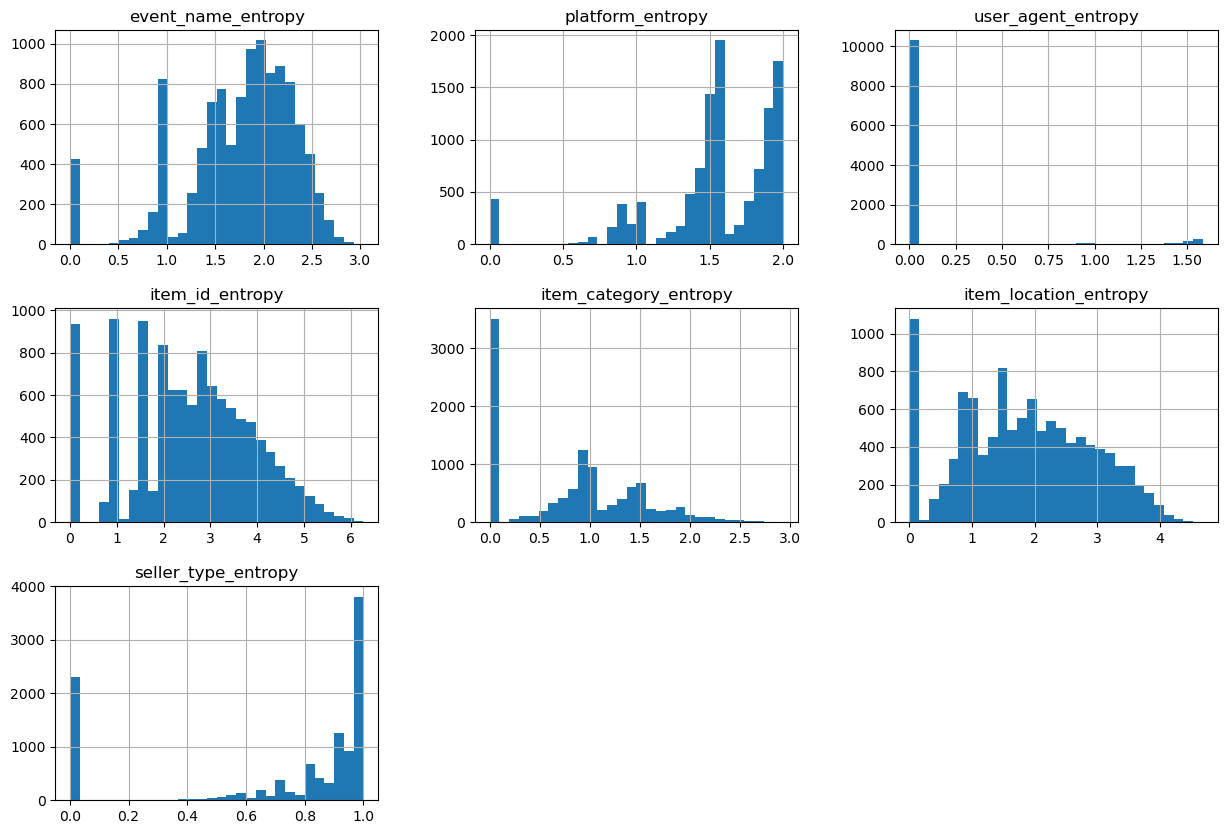

In [28]:
cols = [
    "event_name",
    "platform",
    "user_agent",
    "item_id",
    "item_category",
    "item_location",
    "seller_type",
]

def calc_entropy(x):
    probabilities = (
        x.value_counts(
            normalize=True,
            dropna=True
        )
        .values
    )

    if len(probabilities) == 0:
        return 0.0

    return -np.sum(
        probabilities * np.log2(probabilities)
    )


for col in cols:
    entropies = (
        events
        .groupby("cookie_id")[col]
        .apply(calc_entropy)
    )

    train[f"{col}_entropy"] = (
        train["cookie_id"]
        .map(entropies)
        .fillna(0)
    )

    test[f"{col}_entropy"] = (
        test["cookie_id"]
        .map(entropies)
        .fillna(0)
    )


entropy_cols = [
    f"{col}_entropy"
    for col in cols
]

train[entropy_cols].hist(
    bins=30,
    figsize=(15, 10)
)

print(train.shape)
print(test.shape)

train.head(3)

## Количество действий в минуту и час: среднее, медиана, мода, минимум и максимум

In [29]:
events["event_ts"] = pd.to_datetime(events["event_ts"])

# ============================================================
# 1. Количество событий в каждую минуту
# ============================================================

events["minute"] = events["event_ts"].dt.floor("min")

events_per_minute = (
    events
    .groupby(["cookie_id", "minute"])
    .size()
    .rename("n_events")
    .reset_index()
)

# ============================================================
# 2. Функция для моды
# ============================================================

def get_mode(x):
    mode = x.mode()

    if len(mode) == 0:
        return np.nan

    return mode.iloc[0]

# ============================================================
# 3. Статистики количества событий в минуту
# ============================================================

minute_features = (
    events_per_minute
    .groupby("cookie_id")
    .agg(
        events_per_minute_mean=("n_events", "mean"),
        events_per_minute_median=("n_events", "median"),
        events_per_minute_mode=("n_events", get_mode),
        events_per_minute_min=("n_events", "min"),
        events_per_minute_max=("n_events", "max"),
    )
    .reset_index()
)

# ============================================================
# 4. Количество событий в каждый час
# ============================================================

events["hour"] = events["event_ts"].dt.floor("h")

events_per_hour = (
    events
    .groupby(["cookie_id", "hour"])
    .size()
    .rename("n_events")
    .reset_index()
)

# ============================================================
# 5. Статистики количества событий в час
# ============================================================

hour_features = (
    events_per_hour
    .groupby("cookie_id")
    .agg(
        events_per_hour_mean=("n_events", "mean"),
        events_per_hour_median=("n_events", "median"),
        events_per_hour_mode=("n_events", get_mode),
        events_per_hour_min=("n_events", "min"),
        events_per_hour_max=("n_events", "max"),
    )
    .reset_index()
)

# ============================================================
# 6. Объединяем minute + hour признаки
# ============================================================

activity_features = (
    minute_features
    .merge(
        hour_features,
        on="cookie_id",
        how="outer"
    )
)

# ============================================================
# 7. Округляем среднее и медиану
# ============================================================

round_cols = [
    "events_per_minute_mean",
    "events_per_minute_median",
    "events_per_hour_mean",
    "events_per_hour_median",
]

activity_features[round_cols] = (
    activity_features[round_cols]
    .round(3)
)

# ============================================================
# 8. Добавляем в train и test
# ============================================================

train = train.merge(
    activity_features,
    on="cookie_id",
    how="left"
)

test = test.merge(
    activity_features,
    on="cookie_id",
    how="left"
)

# ============================================================
# 9. Заполняем пропуски
# ============================================================

activity_cols = [
    col
    for col in activity_features.columns
    if col != "cookie_id"
]

train[activity_cols] = train[activity_cols].fillna(0)
test[activity_cols] = test[activity_cols].fillna(0)

print(train.shape)
print(test.shape)

train[["cookie_id"] + activity_cols].head()

(11091, 148)
(4909, 147)


,cookie_id,events_per_minute_mean,events_per_minute_median,events_per_minute_mode,events_per_minute_min,events_per_minute_max,events_per_hour_mean,events_per_hour_median,events_per_hour_mode,events_per_hour_min,events_per_hour_max
0,ck_491599e6793133cb,1.250,1.0,1,1,2,5.000,5.0,4,4,6
1,ck_d6e0cd93b8d1565c,1.538,1.0,1,1,3,3.333,2.5,1,1,9
2,ck_ef82f1d352ec7b10,1.308,1.0,1,1,2,5.667,3.5,1,1,13
3,ck_25b31db8c46573f0,1.357,1.0,1,1,2,6.333,7.0,1,1,11
4,ck_8e5c58cd8631e6dc,1.222,1.0,1,1,2,5.500,5.5,1,1,10


In [30]:
train.head()

,cookie_id,cookie_created_at,target,mean_event_diff_sec,median_event_diff_sec,min_event_diff_sec,max_event_diff_sec,event_diff_entropy,has_zero_event_diff,zero_event_diff_count,concurrent_count,n_intervals,min_lag_sec,median_lag_sec,mean_lag_sec,std_lag_sec,concurrent_ratio,pointer_per_day_mean,pointer_per_day_max,pointer_per_day_min,pointer_per_day_mode,pointer_per_minute_mean,pointer_per_minute_max,pointer_per_minute_min,pointer_per_minute_mode,event_name_count_contact_chat_open,event_name_count_contact_message_sent,event_name_count_contact_phone_show,event_name_count_favorite_add,event_name_count_item_view,event_name_count_login,event_name_count_photo_swipe,event_name_count_search_results_view,event_name_count_seller_page_view,event_pair_count_contact_chat_open__to__contact_chat_open,event_pair_count_contact_chat_open__to__contact_message_sent,event_pair_count_contact_chat_open__to__contact_phone_show,event_pair_count_contact_chat_open__to__favorite_add,event_pair_count_contact_chat_open__to__item_view,event_pair_count_contact_chat_open__to__login,event_pair_count_contact_chat_open__to__photo_swipe,event_pair_count_contact_chat_open__to__search_results_view,event_pair_count_contact_chat_open__to__seller_page_view,event_pair_count_contact_message_sent__to__contact_chat_open,event_pair_count_contact_message_sent__to__contact_message_sent,event_pair_count_contact_message_sent__to__contact_phone_show,event_pair_count_contact_message_sent__to__favorite_add,event_pair_count_contact_message_sent__to__item_view,event_pair_count_contact_message_sent__to__login,event_pair_count_contact_message_sent__to__photo_swipe,event_pair_count_contact_message_sent__to__search_results_view,event_pair_count_contact_message_sent__to__seller_page_view,event_pair_count_contact_phone_show__to__contact_chat_open,event_pair_count_contact_phone_show__to__contact_message_sent,event_pair_count_contact_phone_show__to__contact_phone_show,event_pair_count_contact_phone_show__to__favorite_add,event_pair_count_contact_phone_show__to__item_view,event_pair_count_contact_phone_show__to__login,event_pair_count_contact_phone_show__to__photo_swipe,event_pair_count_contact_phone_show__to__search_results_view,event_pair_count_contact_phone_show__to__seller_page_view,event_pair_count_favorite_add__to__contact_chat_open,event_pair_count_favorite_add__to__contact_message_sent,event_pair_count_favorite_add__to__contact_phone_show,event_pair_count_favorite_add__to__favorite_add,event_pair_count_favorite_add__to__item_view,event_pair_count_favorite_add__to__login,event_pair_count_favorite_add__to__photo_swipe,event_pair_count_favorite_add__to__search_results_view,event_pair_count_favorite_add__to__seller_page_view,event_pair_count_item_view__to__contact_chat_open,event_pair_count_item_view__to__contact_message_sent,event_pair_count_item_view__to__contact_phone_show,event_pair_count_item_view__to__favorite_add,event_pair_count_item_view__to__item_view,event_pair_count_item_view__to__login,event_pair_count_item_view__to__photo_swipe,event_pair_count_item_view__to__search_results_view,event_pair_count_item_view__to__seller_page_view,event_pair_count_login__to__contact_chat_open,event_pair_count_login__to__contact_message_sent,event_pair_count_login__to__contact_phone_show,event_pair_count_login__to__favorite_add,event_pair_count_login__to__item_view,event_pair_count_login__to__login,event_pair_count_login__to__photo_swipe,event_pair_count_login__to__search_results_view,event_pair_count_login__to__seller_page_view,event_pair_count_photo_swipe__to__contact_chat_open,event_pair_count_photo_swipe__to__contact_message_sent,event_pair_count_photo_swipe__to__contact_phone_show,event_pair_count_photo_swipe__to__favorite_add,event_pair_count_photo_swipe__to__item_view,event_pair_count_photo_swipe__to__login,event_pair_count_photo_swipe__to__photo_swipe,event_pair_count_photo_swipe__to__search_results_view,event_pair_count_photo_swipe__to__seller_page_view,event_pair_count_search_results

## Nan ratio

train

In [31]:
nan_ratio = (
    train.isna()
    .mean()
    .mul(100)
    .round(3)
)

nan_ratio = (
    nan_ratio[nan_ratio > 0]
    .sort_values(ascending=False)
)

nan_ratio

std_lag_sec              5.743
mean_event_diff_sec      2.227
median_event_diff_sec    2.227
min_event_diff_sec       2.227
max_event_diff_sec       2.227
event_diff_entropy       2.227
min_lag_sec              2.227
median_lag_sec           2.227
mean_lag_sec             2.227
dtype: float64

test

In [32]:
nan_ratio = (
    test.isna()
    .mean()
    .mul(100)
    .round(3)
)

nan_ratio = (
    nan_ratio[nan_ratio > 0]
    .sort_values(ascending=False)
)

nan_ratio

std_lag_sec              6.030
mean_event_diff_sec      2.119
median_event_diff_sec    2.119
min_event_diff_sec       2.119
max_event_diff_sec       2.119
event_diff_entropy       2.119
min_lag_sec              2.119
median_lag_sec           2.119
mean_lag_sec             2.119
dtype: float64

## Overview

train

In [33]:
unique_counts = (
    train
    .nunique(dropna=False)
    .sort_values()
)

print("=" * 60)
print("UNIQUE VALUES PER FEATURE")
print("=" * 60)
print(unique_counts)

print("\n" + "=" * 60)
print("DATAFRAME INFO")
print("=" * 60)
train.info()

print("\n" + "=" * 60)
print("DATAFRAME SHAPE")
print("=" * 60)
print(f"Rows:    {train.shape[0]}")
print(f"Columns: {train.shape[1]}")

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)

train.head()

UNIQUE VALUES PER FEATURE
event_pair_count_login__to__contact_phone_show                         2
target                                                                 2
event_pair_count_contact_message_sent__to__contact_phone_show          2
event_pair_count_contact_message_sent__to__favorite_add                2
event_pair_count_login__to__contact_message_sent                       2
event_pair_count_contact_message_sent__to__contact_chat_open           2
has_zero_event_diff                                                    2
event_pair_count_contact_message_sent__to__login                       2
event_pair_count_contact_phone_show__to__login                         3
event_pair_count_contact_chat_open__to__favorite_add                   3
event_pair_count_contact_message_sent__to__seller_page_view            3
event_pair_count_contact_chat_open__to__contact_message_sent           3
event_pair_count_contact_chat_open__to__login                          3
event_pair_count_photo_sw

,cookie_id,cookie_created_at,target,mean_event_diff_sec,median_event_diff_sec,min_event_diff_sec,max_event_diff_sec,event_diff_entropy,has_zero_event_diff,zero_event_diff_count,concurrent_count,n_intervals,min_lag_sec,median_lag_sec,mean_lag_sec,std_lag_sec,concurrent_ratio,pointer_per_day_mean,pointer_per_day_max,pointer_per_day_min,pointer_per_day_mode,pointer_per_minute_mean,pointer_per_minute_max,pointer_per_minute_min,pointer_per_minute_mode,event_name_count_contact_chat_open,event_name_count_contact_message_sent,event_name_count_contact_phone_show,event_name_count_favorite_add,event_name_count_item_view,event_name_count_login,event_name_count_photo_swipe,event_name_count_search_results_view,event_name_count_seller_page_view,event_pair_count_contact_chat_open__to__contact_chat_open,event_pair_count_contact_chat_open__to__contact_message_sent,event_pair_count_contact_chat_open__to__contact_phone_show,event_pair_count_contact_chat_open__to__favorite_add,event_pair_count_contact_chat_open__to__item_view,event_pair_count_contact_chat_open__to__login,event_pair_count_contact_chat_open__to__photo_swipe,event_pair_count_contact_chat_open__to__search_results_view,event_pair_count_contact_chat_open__to__seller_page_view,event_pair_count_contact_message_sent__to__contact_chat_open,event_pair_count_contact_message_sent__to__contact_message_sent,event_pair_count_contact_message_sent__to__contact_phone_show,event_pair_count_contact_message_sent__to__favorite_add,event_pair_count_contact_message_sent__to__item_view,event_pair_count_contact_message_sent__to__login,event_pair_count_contact_message_sent__to__photo_swipe,event_pair_count_contact_message_sent__to__search_results_view,event_pair_count_contact_message_sent__to__seller_page_view,event_pair_count_contact_phone_show__to__contact_chat_open,event_pair_count_contact_phone_show__to__contact_message_sent,event_pair_count_contact_phone_show__to__contact_phone_show,event_pair_count_contact_phone_show__to__favorite_add,event_pair_count_contact_phone_show__to__item_view,event_pair_count_contact_phone_show__to__login,event_pair_count_contact_phone_show__to__photo_swipe,event_pair_count_contact_phone_show__to__search_results_view,event_pair_count_contact_phone_show__to__seller_page_view,event_pair_count_favorite_add__to__contact_chat_open,event_pair_count_favorite_add__to__contact_message_sent,event_pair_count_favorite_add__to__contact_phone_show,event_pair_count_favorite_add__to__favorite_add,event_pair_count_favorite_add__to__item_view,event_pair_count_favorite_add__to__login,event_pair_count_favorite_add__to__photo_swipe,event_pair_count_favorite_add__to__search_results_view,event_pair_count_favorite_add__to__seller_page_view,event_pair_count_item_view__to__contact_chat_open,event_pair_count_item_view__to__contact_message_sent,event_pair_count_item_view__to__contact_phone_show,event_pair_count_item_view__to__favorite_add,event_pair_count_item_view__to__item_view,event_pair_count_item_view__to__login,event_pair_count_item_view__to__photo_swipe,event_pair_count_item_view__to__search_results_view,event_pair_count_item_view__to__seller_page_view,event_pair_count_login__to__contact_chat_open,event_pair_count_login__to__contact_message_sent,event_pair_count_login__to__contact_phone_show,event_pair_count_login__to__favorite_add,event_pair_count_login__to__item_view,event_pair_count_login__to__login,event_pair_count_login__to__photo_swipe,event_pair_count_login__to__search_results_view,event_pair_count_login__to__seller_page_view,event_pair_count_photo_swipe__to__contact_chat_open,event_pair_count_photo_swipe__to__contact_message_sent,event_pair_count_photo_swipe__to__contact_phone_show,event_pair_count_photo_swipe__to__favorite_add,event_pair_count_photo_swipe__to__item_view,event_pair_count_photo_swipe__to__login,event_pair_count_photo_swipe__to__photo_swipe,event_pair_count_photo_swipe__to__search_results_view,event_pair_count_photo_swipe__to__seller_page_view,event_pair_count_search_results

In [34]:
object_cols = train.select_dtypes(include="object").columns

print("Object features:")
print(object_cols.tolist())

Object features:
['cookie_id']


test

In [35]:
print(test.info())
print(f"Shape: {test.shape}")
test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Columns: 147 entries, cookie_id to events_per_hour_max
dtypes: datetime64[ns](1), float64(23), int64(122), object(1)
memory usage: 5.5+ MB
None
Shape: (4909, 147)


,cookie_id,cookie_created_at,mean_event_diff_sec,median_event_diff_sec,min_event_diff_sec,max_event_diff_sec,event_diff_entropy,has_zero_event_diff,zero_event_diff_count,concurrent_count,n_intervals,min_lag_sec,median_lag_sec,mean_lag_sec,std_lag_sec,concurrent_ratio,pointer_per_day_mean,pointer_per_day_max,pointer_per_day_min,pointer_per_day_mode,pointer_per_minute_mean,pointer_per_minute_max,pointer_per_minute_min,pointer_per_minute_mode,event_name_count_contact_chat_open,event_name_count_contact_message_sent,event_name_count_contact_phone_show,event_name_count_favorite_add,event_name_count_item_view,event_name_count_login,event_name_count_photo_swipe,event_name_count_search_results_view,event_name_count_seller_page_view,event_pair_count_contact_chat_open__to__contact_chat_open,event_pair_count_contact_chat_open__to__contact_message_sent,event_pair_count_contact_chat_open__to__contact_phone_show,event_pair_count_contact_chat_open__to__favorite_add,event_pair_count_contact_chat_open__to__item_view,event_pair_count_contact_chat_open__to__login,event_pair_count_contact_chat_open__to__photo_swipe,event_pair_count_contact_chat_open__to__search_results_view,event_pair_count_contact_chat_open__to__seller_page_view,event_pair_count_contact_message_sent__to__contact_chat_open,event_pair_count_contact_message_sent__to__contact_message_sent,event_pair_count_contact_message_sent__to__contact_phone_show,event_pair_count_contact_message_sent__to__favorite_add,event_pair_count_contact_message_sent__to__item_view,event_pair_count_contact_message_sent__to__login,event_pair_count_contact_message_sent__to__photo_swipe,event_pair_count_contact_message_sent__to__search_results_view,event_pair_count_contact_message_sent__to__seller_page_view,event_pair_count_contact_phone_show__to__contact_chat_open,event_pair_count_contact_phone_show__to__contact_message_sent,event_pair_count_contact_phone_show__to__contact_phone_show,event_pair_count_contact_phone_show__to__favorite_add,event_pair_count_contact_phone_show__to__item_view,event_pair_count_contact_phone_show__to__login,event_pair_count_contact_phone_show__to__photo_swipe,event_pair_count_contact_phone_show__to__search_results_view,event_pair_count_contact_phone_show__to__seller_page_view,event_pair_count_favorite_add__to__contact_chat_open,event_pair_count_favorite_add__to__contact_message_sent,event_pair_count_favorite_add__to__contact_phone_show,event_pair_count_favorite_add__to__favorite_add,event_pair_count_favorite_add__to__item_view,event_pair_count_favorite_add__to__login,event_pair_count_favorite_add__to__photo_swipe,event_pair_count_favorite_add__to__search_results_view,event_pair_count_favorite_add__to__seller_page_view,event_pair_count_item_view__to__contact_chat_open,event_pair_count_item_view__to__contact_message_sent,event_pair_count_item_view__to__contact_phone_show,event_pair_count_item_view__to__favorite_add,event_pair_count_item_view__to__item_view,event_pair_count_item_view__to__login,event_pair_count_item_view__to__photo_swipe,event_pair_count_item_view__to__search_results_view,event_pair_count_item_view__to__seller_page_view,event_pair_count_login__to__contact_chat_open,event_pair_count_login__to__contact_message_sent,event_pair_count_login__to__contact_phone_show,event_pair_count_login__to__favorite_add,event_pair_count_login__to__item_view,event_pair_count_login__to__login,event_pair_count_login__to__photo_swipe,event_pair_count_login__to__search_results_view,event_pair_count_login__to__seller_page_view,event_pair_count_photo_swipe__to__contact_chat_open,event_pair_count_photo_swipe__to__contact_message_sent,event_pair_count_photo_swipe__to__contact_phone_show,event_pair_count_photo_swipe__to__favorite_add,event_pair_count_photo_swipe__to__item_view,event_pair_count_photo_swipe__to__login,event_pair_count_photo_swipe__to__photo_swipe,event_pair_count_photo_swipe__to__search_results_view,event_pair_count_photo_swipe__to__seller_page_view,event_pair_count_search_results_view__

## Feature types

Категориальные, бинарные и числовые признаки

In [36]:
categorical_features = [
    "event_name_mode",
    "platform_mode",
    "user_agent_mode",
    "item_id_mode",
    "item_category_mode",
    "item_location_mode",
    "seller_type_mode",
]

binary_features = [
    "event_pair_count_login__to__contact_phone_show",
    "event_pair_count_contact_message_sent__to__contact_phone_show",
    "event_pair_count_contact_message_sent__to__favorite_add",
    "event_pair_count_login__to__contact_message_sent",
    "event_pair_count_contact_message_sent__to__contact_chat_open",
    "has_zero_event_diff",
    "event_pair_count_contact_message_sent__to__login",
]

exclude_features = [
    "target",
    "cookie_id",
    "cookie_created_at",
]

numerical_features = [
    col
    for col in train.columns
    if col not in (
        categorical_features
        + binary_features
        + exclude_features
    )
]

In [37]:
print(train.shape)
print(test.shape)

(11091, 148)
(4909, 147)


# Preprocessing

## Check for train test shift

## Check for linear dependencies

### Hot map

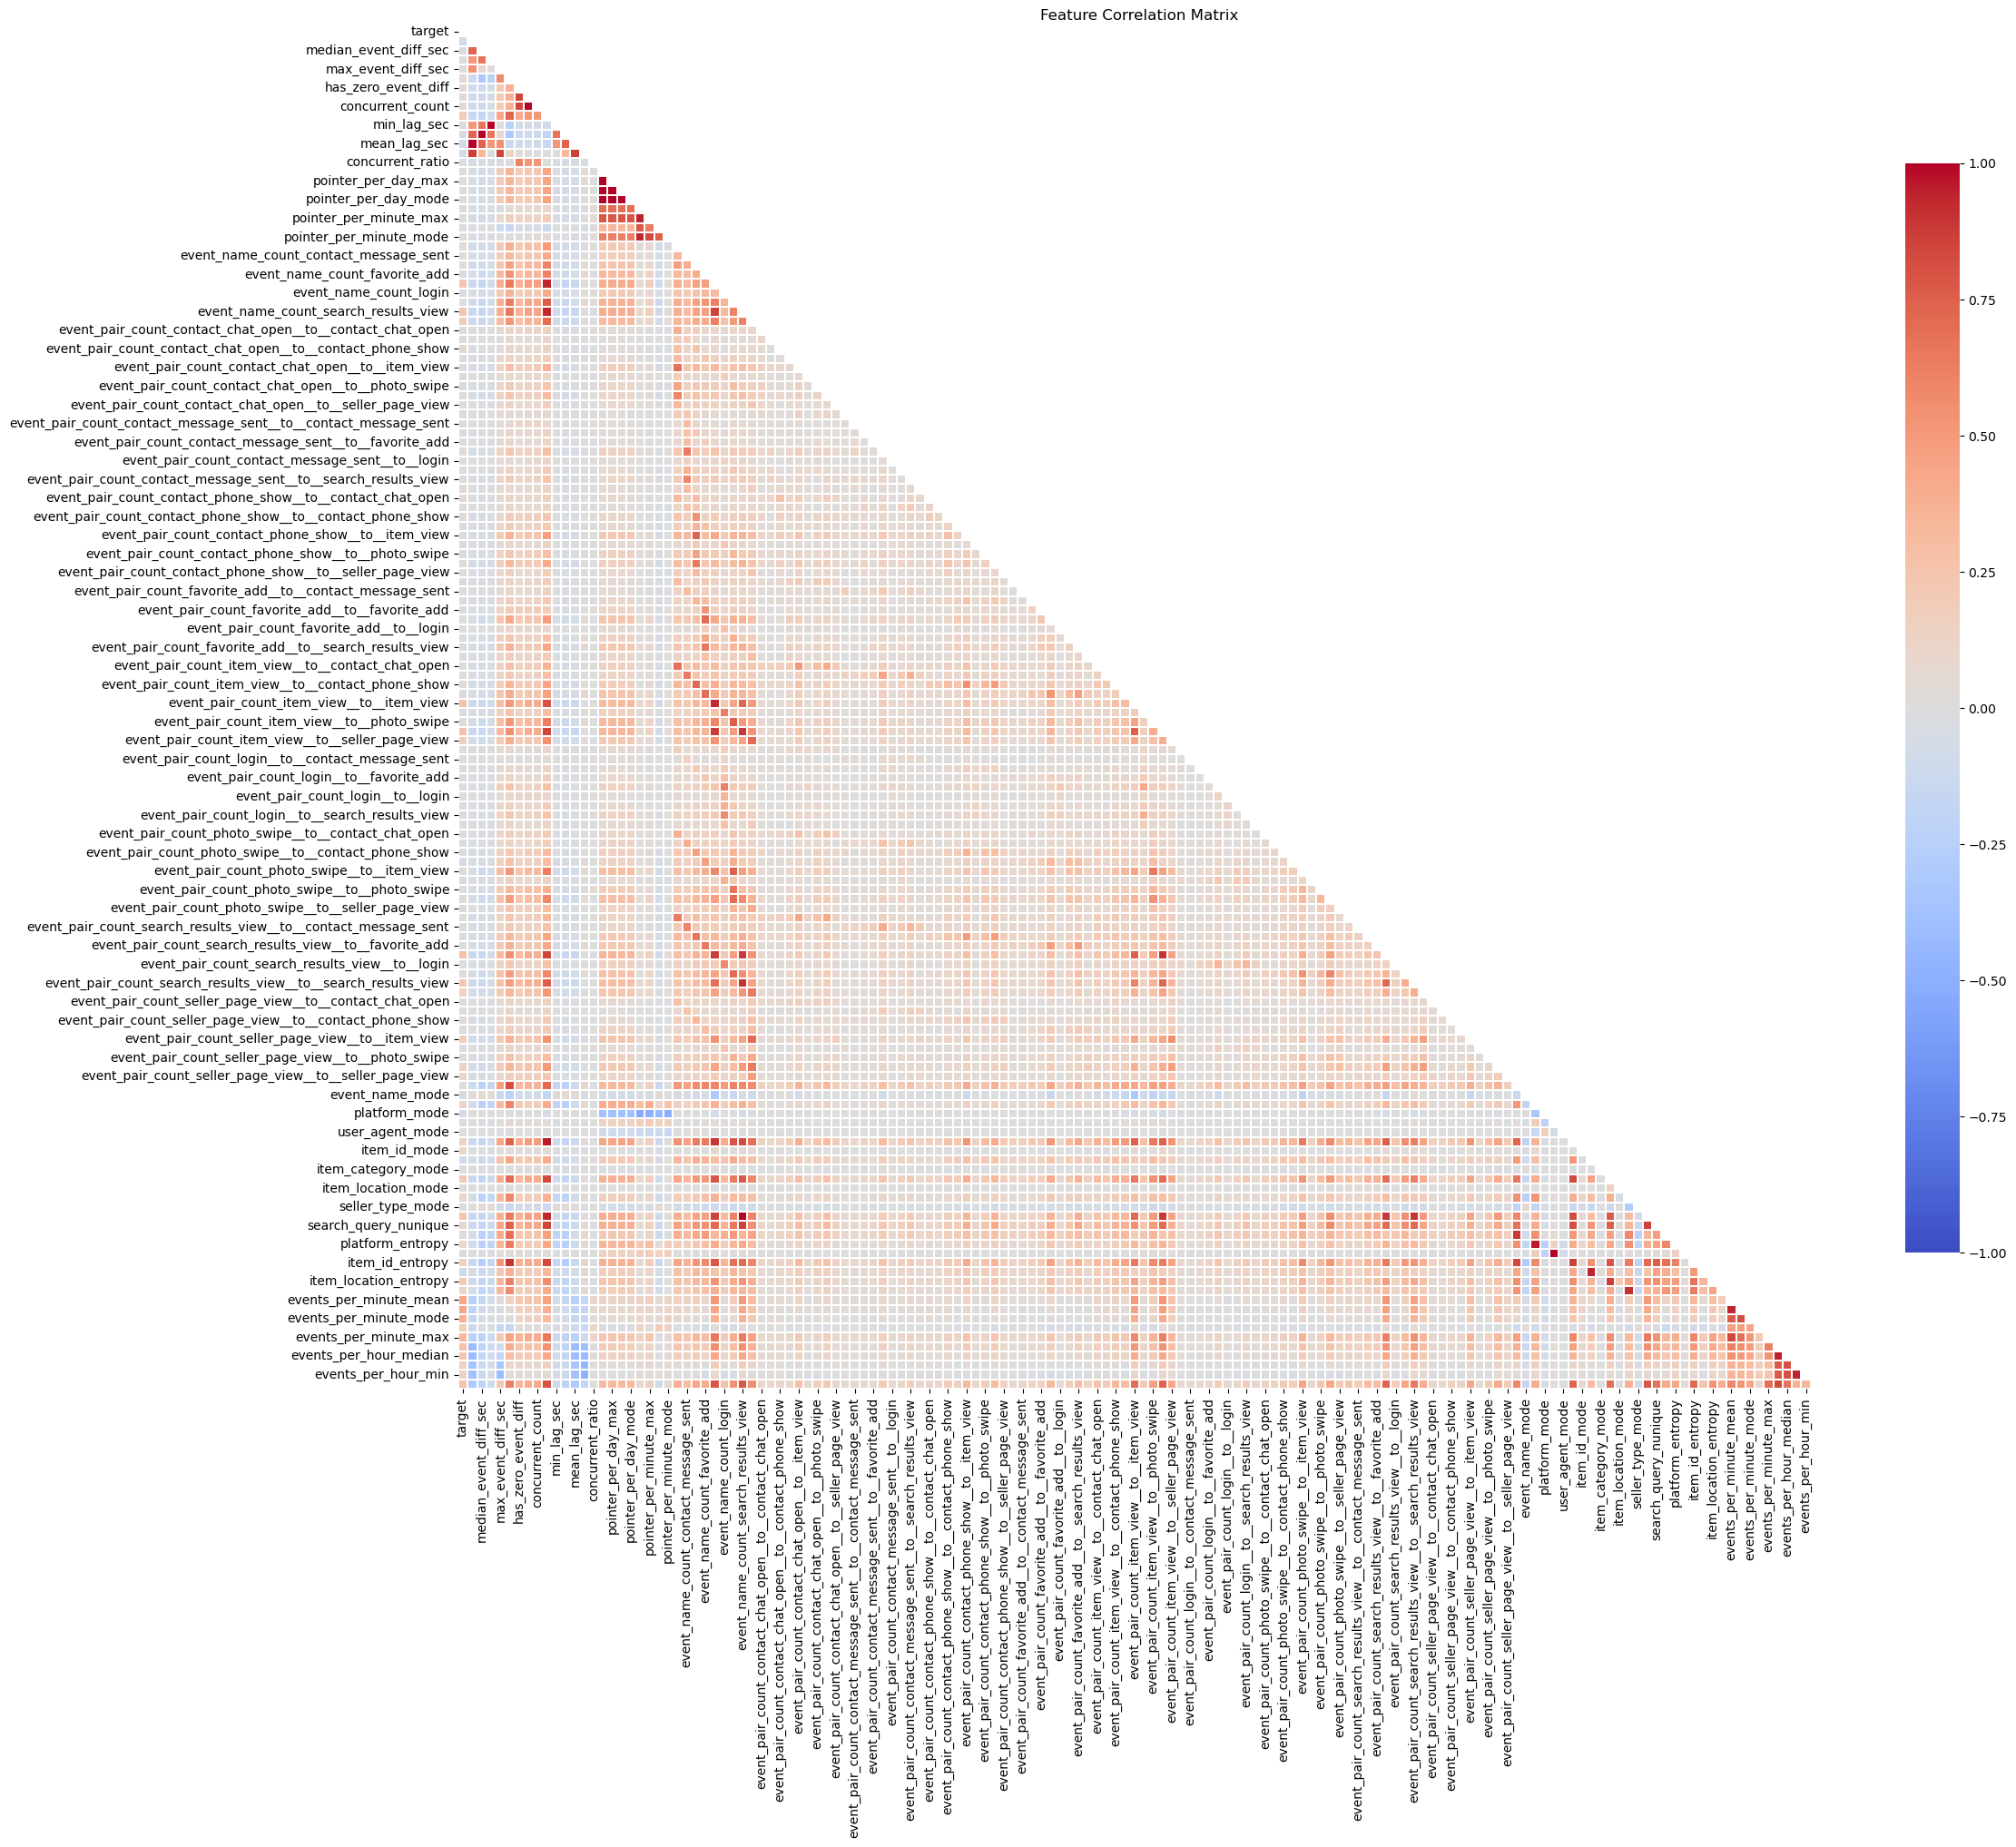

Feature pairs with |correlation| >= 0.85:
                                                    feature_1                                                     feature_2  correlation
                                          pointer_per_day_max                                          pointer_per_day_mode     1.000000
                                        median_event_diff_sec                                                median_lag_sec     1.000000
                                           min_event_diff_sec                                                   min_lag_sec     1.000000
                                        zero_event_diff_count                                              concurrent_count     1.000000
                         event_name_count_search_results_view                                            search_query_count     1.000000
                                          pointer_per_day_min                                          pointer_per_day_mode     1.000000

In [40]:
corr = train.select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(24, 20))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


# Correlations with |corr| >= 0.85
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
high_corr = (
    upper.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2"
    })
)
high_corr = (
    high_corr[high_corr["correlation"].abs() >= 0.85]
    .assign(abs_correlation=lambda x: x["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
    .drop(columns="abs_correlation")
)
print("Feature pairs with |correlation| >= 0.85:")
print(high_corr.to_string(index=False))

In [41]:
print(train.shape)
print(test.shape)

(11091, 148)
(4909, 147)


### Delete high linear corr

Удалить, где |лин корр| >= 0.95

Признаки с высокой корреляцией стоит убрать, так как они могут ухудшать baseline-модель — Logistic Regression — из-за мультиколлинеарности. Кроме того, сильно коррелирующие признаки во многом дублируют информацию. В идеале из каждой пары стоит удалять менее осмысленный признак, но ради скорости в данном случае удаляется любой из пары.

In [42]:
threshold = 0.95
cols_to_drop = []

while True:
    features = train.drop(columns=["target"], errors="ignore").select_dtypes(include="number")
    corr = features.corr().abs()

    upper = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    pairs = upper.stack()

    if pairs.empty or pairs.max() < threshold:
        break

    feature_1, feature_2 = pairs.idxmax()
    correlation = pairs.max()

    train = train.drop(columns=[feature_2])
    test = test.drop(columns=[feature_2])
    cols_to_drop.append(feature_2)

    print(
        f"Dropped: {feature_2} "
        f"(correlation with {feature_1}: {correlation:.3f})"
    )

print(f"\nDropped features: {len(cols_to_drop)}")
print(cols_to_drop)
print(f"New shape: {train.shape}")

Dropped: median_lag_sec (correlation with median_event_diff_sec: 1.000)
Dropped: min_lag_sec (correlation with min_event_diff_sec: 1.000)
Dropped: concurrent_count (correlation with zero_event_diff_count: 1.000)
Dropped: pointer_per_day_max (correlation with pointer_per_day_mean: 1.000)
Dropped: pointer_per_day_min (correlation with pointer_per_day_mean: 1.000)
Dropped: pointer_per_day_mode (correlation with pointer_per_day_mean: 1.000)
Dropped: search_query_count (correlation with event_name_count_search_results_view: 1.000)
Dropped: mean_lag_sec (correlation with mean_event_diff_sec: 1.000)
Dropped: user_agent_entropy (correlation with user_agent_nunique: 0.997)
Dropped: item_id_nunique (correlation with n_intervals: 0.958)
Dropped: platform_entropy (correlation with platform_nunique: 0.954)
Dropped: events_per_hour_median (correlation with events_per_hour_mean: 0.953)

Dropped features: 12
['median_lag_sec', 'min_lag_sec', 'concurrent_count', 'pointer_per_day_max', 'pointer_per_day_

In [43]:
print(train.shape)
print(test.shape)

(11091, 136)
(4909, 135)


## Check for Nan

In [44]:
nan_ratio = (
    train.isna()
    .mean()
    .mul(100)
    .round(3)
)

nan_ratio = (
    nan_ratio[nan_ratio > 0]
    .sort_values(ascending=False)
)

nan_ratio

std_lag_sec              5.743
mean_event_diff_sec      2.227
median_event_diff_sec    2.227
min_event_diff_sec       2.227
max_event_diff_sec       2.227
event_diff_entropy       2.227
dtype: float64

От характера признака зависит какая стратегия заполнения Nan. 

Количество Nan небольшое. Для log reg стоит их импутировать. Для моделей град бустов имппутация пропущена.

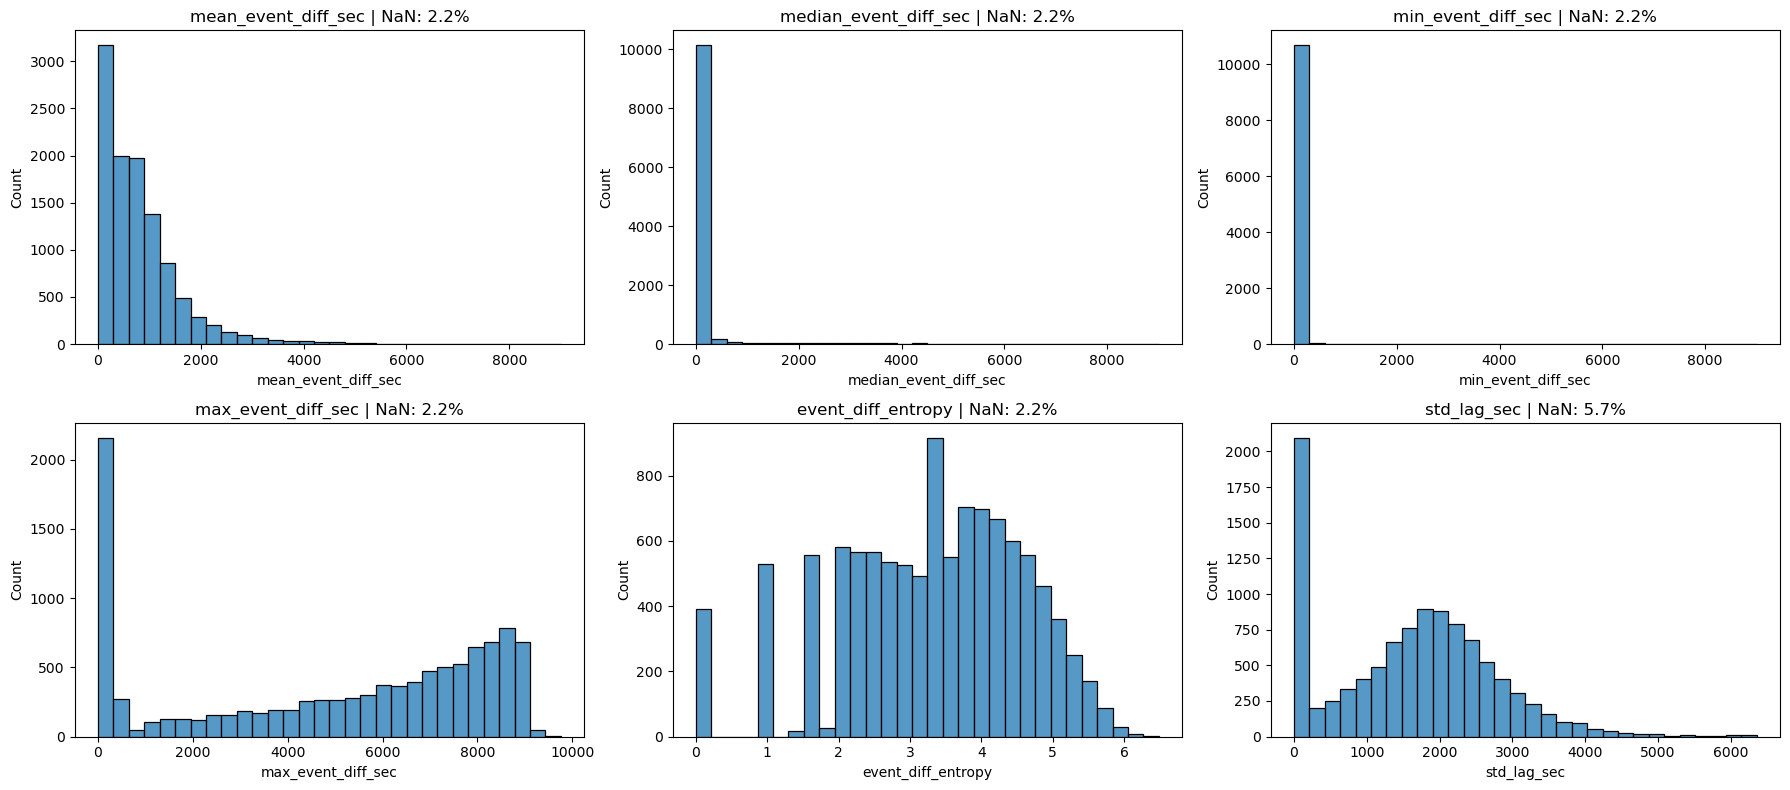

In [45]:
nan_features = train.columns[train.isna().any()]

n_cols = 3
n_rows = int(np.ceil(len(nan_features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(nan_features):
    sns.histplot(
        train[feature].dropna(),
        bins=30,
        ax=axes[i]
    )

    nan_percent = train[feature].isna().mean() * 100

    axes[i].set_title(
        f"{feature} | NaN: {nan_percent:.1f}%"
    )

    axes[i].set_xlabel(feature)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

test

In [46]:
nan_ratio = (
    train.isna()
    .mean()
    .mul(100)
    .round(3)
)

nan_ratio = (
    nan_ratio[nan_ratio > 0]
    .sort_values(ascending=False)
)

nan_ratio

std_lag_sec              5.743
mean_event_diff_sec      2.227
median_event_diff_sec    2.227
min_event_diff_sec       2.227
max_event_diff_sec       2.227
event_diff_entropy       2.227
dtype: float64

In [47]:
print(train.shape)
print(test.shape)

(11091, 136)
(4909, 135)


# Feature Types

In [65]:
dropped_features = [
    "median_lag_sec",
    "min_lag_sec",
    "concurrent_count",
    "pointer_per_day_max",
    "pointer_per_day_min",
    "pointer_per_day_mode",
    "search_query_count",
    "mean_lag_sec",
    "user_agent_entropy",
    "item_id_nunique",
    "platform_entropy",
    "events_per_hour_median",
]

categorical_features = [
    "event_name_mode",
    "platform_mode",
    "user_agent_mode",
    "item_id_mode",
    "item_category_mode",
    "item_location_mode",
    "seller_type_mode",
]

binary_features = [
    "event_pair_count_login__to__contact_phone_show",
    "event_pair_count_contact_message_sent__to__contact_phone_show",
    "event_pair_count_contact_message_sent__to__favorite_add",
    "event_pair_count_login__to__contact_message_sent",
    "event_pair_count_contact_message_sent__to__contact_chat_open",
    "has_zero_event_diff",
    "event_pair_count_contact_message_sent__to__login",
]

exclude_features = [
    "target",
    "cookie_id",
    "cookie_created_at",
]

numerical_features = [
    col
    for col in train.columns
    if col not in (
        categorical_features
        + binary_features
        + exclude_features
        + dropped_features
    )
]

# Eval

## Baseline. Log Reg

### Split

In [71]:
# Доп. сортировка
train = (
    train
    .sort_values("cookie_created_at")
    .reset_index(drop=True)
)

X = train.drop(
    columns=["target", "cookie_id", "cookie_created_at"]
).copy()

y = train["target"].copy()

split_idx = int(len(train) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train: (8872, 133)
Test: (2219, 133)
Train positive rate: 0.059963931469792606
Test positive rate: 0.1653898152320865


### Fit

In [ ]:
cv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    C = trial.suggest_float("C", 1e-3, 20.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.1, 0.9) if penalty == "elasticnet" else None

    mode_cols = [
        "mean_event_diff_sec",
        "median_event_diff_sec",
        "min_event_diff_sec",
        "max_event_diff_sec",
        "event_diff_entropy",
        "std_lag_sec",
    ]
    
    median_cols = [
        col for col in numerical_features
        if col not in mode_cols
    ]
    
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    
    binary_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])
    
    numerical_mode_pipeline = Pipeline([
        ("imputer", SimpleImputer(
            strategy="most_frequent",
            add_indicator=True
        )),
        ("scaler", StandardScaler()),
    ])
    
    numerical_median_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    
    preprocessor = ColumnTransformer([
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            binary_features
        ),
        (
            "numerical_mode",
            numerical_mode_pipeline,
            mode_cols
        ),
        (
            "numerical_median",
            numerical_median_pipeline,
            median_cols
        ),
    ])
    
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("logreg", LogisticRegression(
            C=C,
            penalty=penalty,
            solver="saga",
            l1_ratio=l1_ratio,
            max_iter=5000,
            random_state=random_state
        ))
    ])

    roc_scores, pr_scores = [], []

    for train_idx, valid_idx in cv.split(X_train):
        X_fold_train, X_fold_valid = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_fold_train, y_fold_valid = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        if y_fold_valid.nunique() < 2:
            continue

        model.fit(X_fold_train, y_fold_train)
        y_pred_proba = model.predict_proba(X_fold_valid)[:, 1]

        roc_scores.append(roc_auc_score(y_fold_valid, y_pred_proba))
        pr_scores.append(average_precision_score(y_fold_valid, y_pred_proba))

    if not pr_scores:
        return 0.0

    mean_roc = np.mean(roc_scores)
    mean_pr = np.mean(pr_scores)

    trial.set_user_attr("roc_auc", mean_roc)
    trial.set_user_attr("pr_auc", mean_pr)

    return mean_pr


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, n_jobs=-1)

best_trial = study.best_trial

print(f"Best score: {study.best_value:.4f}")
print(f"ROC AUC CV: {best_trial.user_attrs['roc_auc']:.4f}")
print(f"PR AUC CV:  {best_trial.user_attrs['pr_auc']:.4f}")
print("\nBest params:")
print(study.best_params)

[I 2026-09-28 23:06:44,084] A new study created in memory with name: no-name-2604f7d5-ed20-4f35-9b2c-cda737b4dc59


In [ ]:
mode_cols = [
    "mean_event_diff_sec",
    "median_event_diff_sec",
    "min_event_diff_sec",
    "max_event_diff_sec",
    "event_diff_entropy",
    "std_lag_sec",
]

median_cols = [
    col for col in numerical_features
    if col not in mode_cols
]

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

numerical_mode_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="most_frequent",
        add_indicator=True
    )),
    ("scaler", StandardScaler()),
])

numerical_median_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
    (
        "binary",
        binary_pipeline,
        binary_features
    ),
    (
        "numerical_mode",
        numerical_mode_pipeline,
        mode_cols
    ),
    (
        "numerical_median",
        numerical_median_pipeline,
        median_cols
    ),
])

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("logreg", LogisticRegression(
        C=C,
        penalty=penalty,
        solver="saga",
        l1_ratio=l1_ratio,
        max_iter=5000,
        random_state=random_state
    ))
])

final_model.fit(
    X_train,
    y_train
)
joblib.dump(final_model, "./models/log_reg_optuna.pkl")

y_test_proba = final_model.predict_proba(
    X_test
)[:, 1]

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print(f"ROC AUC: {test_roc_auc:.4f}")
print(f"PR AUC:  {test_pr_auc:.4f}")

### Score

In [ ]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(4, 4))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM ROC AUC = {test_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

baseline = y_test.mean()

plt.figure(figsize=(4, 4))

plt.plot(
    recall,
    precision,
    label=f"LightGBM PR AUC = {test_pr_auc:.4f}"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:


# ==========================================
# Thresholds
# ==========================================

thresholds = np.linspace(0, 1, 1001)

precisions = []
recalls = []
accuracies = []

for threshold in thresholds:

    y_pred = (
        y_test_proba >= threshold
    ).astype(int)

    precisions.append(
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    recalls.append(
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    accuracies.append(
        accuracy_score(
            y_test,
            y_pred
        )
    )


precisions = np.array(precisions)
recalls = np.array(recalls)
accuracies = np.array(accuracies)


# ==========================================
# Best Precision при Recall >= 0.70
# ==========================================

min_recall = 0.70

valid = recalls >= min_recall

best_idx = np.where(valid)[0][
    np.argmax(precisions[valid])
]

best_threshold = thresholds[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]
best_accuracy = accuracies[best_idx]


print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision:      {best_precision:.4f}")
print(f"Recall:         {best_recall:.4f}")
print(f"Accuracy:       {best_accuracy:.4f}")


# ==========================================
# Plotly
# ==========================================

fig = go.Figure()


# Precision
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=precisions,
        mode="lines",
        name="Precision",
        line=dict(width=2)
    )
)


# Recall
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=recalls,
        mode="lines",
        name="Recall",
        line=dict(width=2)
    )
)


# Accuracy
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=accuracies,
        mode="lines",
        name="Accuracy",
        line=dict(width=2),
        opacity=0.7
    )
)


# ==========================================
# Минимальный Recall
# ==========================================

fig.add_hline(
    y=min_recall,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Min Recall = {min_recall:.0%}",
    annotation_position="bottom right"
)


# ==========================================
# Лучший threshold
# ==========================================

fig.add_vline(
    x=best_threshold,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Threshold = {best_threshold:.3f}",
    annotation_position="top"
)


# ==========================================
# Точки выбранных Precision и Recall
# ==========================================

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_precision],
        mode="markers",
        name="Best Precision",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Precision: {best_precision:.3f}<br>"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_recall],
        mode="markers",
        name="Recall at best threshold",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Recall: {best_recall:.3f}<br>"
            "<extra></extra>"
        )
    )
)


# ==========================================
# Annotation
# ==========================================

fig.add_annotation(
    x=0.98,
    y=0.98,
    xref="paper",
    yref="paper",

    text=(
        f"<b>Best threshold</b><br>"
        f"Threshold = {best_threshold:.3f}<br>"
        f"Precision = {best_precision:.3f}<br>"
        f"Recall = {best_recall:.3f}<br>"
        f"Accuracy = {best_accuracy:.3f}"
    ),

    showarrow=False,

    xanchor="right",
    yanchor="top",

    bgcolor="white",
    bordercolor="gray",
    borderwidth=1,
    borderpad=6
)


# ==========================================
# Layout
# ==========================================

fig.update_layout(
    width=600,
    height=600,

    title=(
        "Precision / Recall / Accuracy vs Threshold"
        "<br>"
        "<sup>Best Precision subject to Recall ≥ 70%</sup>"
    ),

    xaxis_title="Classification Threshold",
    yaxis_title="Metric",

    xaxis=dict(
        range=[0, 1]
    ),

    yaxis=dict(
        range=[0, 1.05]
    ),

    hovermode="x unified",

    legend=dict(
        x=0.02,
        y=0.02,
        xanchor="left",
        yanchor="bottom"
    ),

    margin=dict(
        l=70,
        r=30,
        t=90,
        b=70
    )
)


fig.show()

## Catboost

### Split

In [54]:
# Доп. сортировка
train = (
    train
    .sort_values("cookie_created_at")
    .reset_index(drop=True)
)

X = train.drop(
    columns=["target", "cookie_id", "cookie_created_at"]
).copy()

y = train["target"].copy()

split_idx = int(len(train) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train: (8872, 133)
Test: (2219, 133)
Train positive rate: 0.059963931469792606
Test positive rate: 0.1653898152320865


### Fit

In [55]:
model = CatBoostClassifier(
    loss_function="Logloss",
    cat_features=categorical_features,
    random_seed=random_state,
    thread_count=-1,
    verbose=False
)
model.fit(
    X_train,
    y_train
)
joblib.dump(model, "./models/catboost.pkl")

y_test_proba = model.predict_proba(
    X_test
)[:, 1]

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print(f"Test ROC AUC: {test_roc_auc:.4f}")
print(f"Test PR AUC:  {test_pr_auc:.4f}")

Test ROC AUC: 0.9118
Test PR AUC:  0.7928


### Score

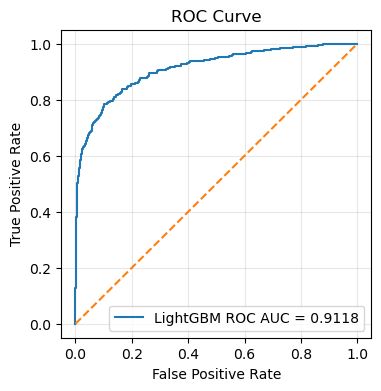

In [56]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(4, 4))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM ROC AUC = {test_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

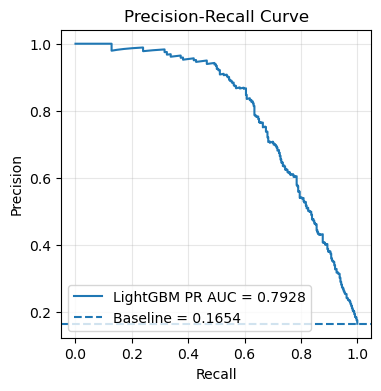

In [57]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

baseline = y_test.mean()

plt.figure(figsize=(4, 4))

plt.plot(
    recall,
    precision,
    label=f"LightGBM PR AUC = {test_pr_auc:.4f}"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Best threshold: 0.154
Precision:      0.7080
Recall:         0.7003
Accuracy:       0.9027


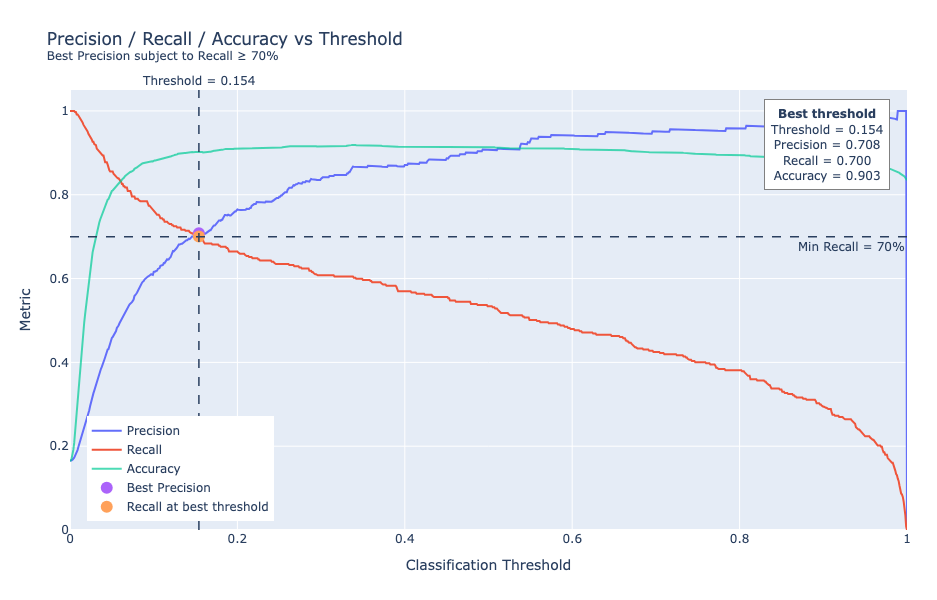

In [58]:


# ==========================================
# Thresholds
# ==========================================

thresholds = np.linspace(0, 1, 1001)

precisions = []
recalls = []
accuracies = []

for threshold in thresholds:

    y_pred = (
        y_test_proba >= threshold
    ).astype(int)

    precisions.append(
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    recalls.append(
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    accuracies.append(
        accuracy_score(
            y_test,
            y_pred
        )
    )


precisions = np.array(precisions)
recalls = np.array(recalls)
accuracies = np.array(accuracies)


# ==========================================
# Best Precision при Recall >= 0.70
# ==========================================

min_recall = 0.70

valid = recalls >= min_recall

best_idx = np.where(valid)[0][
    np.argmax(precisions[valid])
]

best_threshold = thresholds[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]
best_accuracy = accuracies[best_idx]


print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision:      {best_precision:.4f}")
print(f"Recall:         {best_recall:.4f}")
print(f"Accuracy:       {best_accuracy:.4f}")


# ==========================================
# Plotly
# ==========================================

fig = go.Figure()


# Precision
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=precisions,
        mode="lines",
        name="Precision",
        line=dict(width=2)
    )
)


# Recall
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=recalls,
        mode="lines",
        name="Recall",
        line=dict(width=2)
    )
)


# Accuracy
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=accuracies,
        mode="lines",
        name="Accuracy",
        line=dict(width=2),
        opacity=0.7
    )
)


# ==========================================
# Минимальный Recall
# ==========================================

fig.add_hline(
    y=min_recall,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Min Recall = {min_recall:.0%}",
    annotation_position="bottom right"
)


# ==========================================
# Лучший threshold
# ==========================================

fig.add_vline(
    x=best_threshold,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Threshold = {best_threshold:.3f}",
    annotation_position="top"
)


# ==========================================
# Точки выбранных Precision и Recall
# ==========================================

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_precision],
        mode="markers",
        name="Best Precision",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Precision: {best_precision:.3f}<br>"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_recall],
        mode="markers",
        name="Recall at best threshold",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Recall: {best_recall:.3f}<br>"
            "<extra></extra>"
        )
    )
)


# ==========================================
# Annotation
# ==========================================

fig.add_annotation(
    x=0.98,
    y=0.98,
    xref="paper",
    yref="paper",

    text=(
        f"<b>Best threshold</b><br>"
        f"Threshold = {best_threshold:.3f}<br>"
        f"Precision = {best_precision:.3f}<br>"
        f"Recall = {best_recall:.3f}<br>"
        f"Accuracy = {best_accuracy:.3f}"
    ),

    showarrow=False,

    xanchor="right",
    yanchor="top",

    bgcolor="white",
    bordercolor="gray",
    borderwidth=1,
    borderpad=6
)


# ==========================================
# Layout
# ==========================================

fig.update_layout(
    width=600,
    height=600,

    title=(
        "Precision / Recall / Accuracy vs Threshold"
        "<br>"
        "<sup>Best Precision subject to Recall ≥ 70%</sup>"
    ),

    xaxis_title="Classification Threshold",
    yaxis_title="Metric",

    xaxis=dict(
        range=[0, 1]
    ),

    yaxis=dict(
        range=[0, 1.05]
    ),

    hovermode="x unified",

    legend=dict(
        x=0.02,
        y=0.02,
        xanchor="left",
        yanchor="bottom"
    ),

    margin=dict(
        l=70,
        r=30,
        t=90,
        b=70
    )
)


fig.show()

## LightGBM

### Split

In [93]:
# Доп. сортировка
train = (
    train
    .sort_values("cookie_created_at")
    .reset_index(drop=True)
)

X = train.drop(
    columns=["target", "cookie_id", "cookie_created_at"]
).copy()

y = train["target"].copy()

split_idx = int(len(train) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

for col in categorical_features:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train: (8872, 133)
Test: (2219, 133)
Train positive rate: 0.059963931469792606
Test positive rate: 0.1653898152320865


/var/folders/56/8540xfg53s7g7scydlxl99dm0000gn/T/ipykernel_38874/3116376846.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype("category")
/var/folders/56/8540xfg53s7g7scydlxl99dm0000gn/T/ipykernel_38874/3116376846.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].astype("category")
/var/folders/56/8540xfg53s7g7scydlxl99dm0000gn/T/ipykernel_38874/3116376846.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

In [94]:
X_train.head(2)

,mean_event_diff_sec,median_event_diff_sec,min_event_diff_sec,max_event_diff_sec,event_diff_entropy,has_zero_event_diff,zero_event_diff_count,n_intervals,std_lag_sec,concurrent_ratio,pointer_per_day_mean,pointer_per_minute_mean,pointer_per_minute_max,pointer_per_minute_min,pointer_per_minute_mode,event_name_count_contact_chat_open,event_name_count_contact_message_sent,event_name_count_contact_phone_show,event_name_count_favorite_add,event_name_count_item_view,event_name_count_login,event_name_count_photo_swipe,event_name_count_search_results_view,event_name_count_seller_page_view,event_pair_count_contact_chat_open__to__contact_chat_open,event_pair_count_contact_chat_open__to__contact_message_sent,event_pair_count_contact_chat_open__to__contact_phone_show,event_pair_count_contact_chat_open__to__favorite_add,event_pair_count_contact_chat_open__to__item_view,event_pair_count_contact_chat_open__to__login,event_pair_count_contact_chat_open__to__photo_swipe,event_pair_count_contact_chat_open__to__search_results_view,event_pair_count_contact_chat_open__to__seller_page_view,event_pair_count_contact_message_sent__to__contact_chat_open,event_pair_count_contact_message_sent__to__contact_message_sent,event_pair_count_contact_message_sent__to__contact_phone_show,event_pair_count_contact_message_sent__to__favorite_add,event_pair_count_contact_message_sent__to__item_view,event_pair_count_contact_message_sent__to__login,event_pair_count_contact_message_sent__to__photo_swipe,event_pair_count_contact_message_sent__to__search_results_view,event_pair_count_contact_message_sent__to__seller_page_view,event_pair_count_contact_phone_show__to__contact_chat_open,event_pair_count_contact_phone_show__to__contact_message_sent,event_pair_count_contact_phone_show__to__contact_phone_show,event_pair_count_contact_phone_show__to__favorite_add,event_pair_count_contact_phone_show__to__item_view,event_pair_count_contact_phone_show__to__login,event_pair_count_contact_phone_show__to__photo_swipe,event_pair_count_contact_phone_show__to__search_results_view,event_pair_count_contact_phone_show__to__seller_page_view,event_pair_count_favorite_add__to__contact_chat_open,event_pair_count_favorite_add__to__contact_message_sent,event_pair_count_favorite_add__to__contact_phone_show,event_pair_count_favorite_add__to__favorite_add,event_pair_count_favorite_add__to__item_view,event_pair_count_favorite_add__to__login,event_pair_count_favorite_add__to__photo_swipe,event_pair_count_favorite_add__to__search_results_view,event_pair_count_favorite_add__to__seller_page_view,event_pair_count_item_view__to__contact_chat_open,event_pair_count_item_view__to__contact_message_sent,event_pair_count_item_view__to__contact_phone_show,event_pair_count_item_view__to__favorite_add,event_pair_count_item_view__to__item_view,event_pair_count_item_view__to__login,event_pair_count_item_view__to__photo_swipe,event_pair_count_item_view__to__search_results_view,event_pair_count_item_view__to__seller_page_view,event_pair_count_login__to__contact_chat_open,event_pair_count_login__to__contact_message_sent,event_pair_count_login__to__contact_phone_show,event_pair_count_login__to__favorite_add,event_pair_count_login__to__item_view,event_pair_count_login__to__login,event_pair_count_login__to__photo_swipe,event_pair_count_login__to__search_results_view,event_pair_count_login__to__seller_page_view,event_pair_count_photo_swipe__to__contact_chat_open,event_pair_count_photo_swipe__to__contact_message_sent,event_pair_count_photo_swipe__to__contact_phone_show,event_pair_count_photo_swipe__to__favorite_add,event_pair_count_photo_swipe__to__item_view,event_pair_count_photo_swipe__to__login,event_pair_count_photo_swipe__to__photo_swipe,event_pair_count_photo_swipe__to__search_results_view,event_pair_count_photo_swipe__to__seller_page_view,event_pair_count_search_results_view__to__contact_chat_open,event_pair_count_search_results_view__to__contact_message_sent,event_pair_count_search_results_view__to__contact_phone_show,

### Fit

In [95]:
model = lgb.LGBMClassifier(
    objective="binary",
    random_state=random_state,
    n_jobs=-1,
    verbosity=-1
)
model.fit(
    X_train,
    y_train
)
joblib.dump(model, "./models/lightGBM.pkl")

y_test_proba = model.predict_proba(
    X_test
)[:, 1]

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print(f"Test ROC AUC: {test_roc_auc:.4f}")
print(f"Test PR AUC:  {test_pr_auc:.4f}")

Test ROC AUC: 0.8974
Test PR AUC:  0.7691


### Score

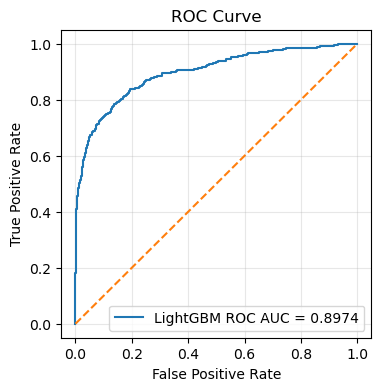

In [96]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(4, 4))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM ROC AUC = {test_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

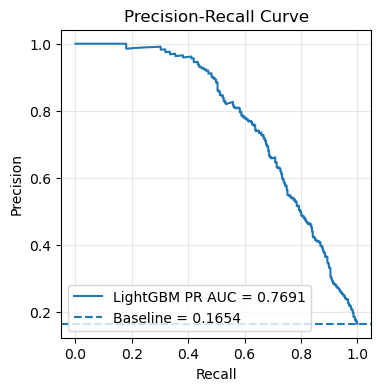

In [97]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

baseline = y_test.mean()

plt.figure(figsize=(4, 4))

plt.plot(
    recall,
    precision,
    label=f"LightGBM PR AUC = {test_pr_auc:.4f}"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Best threshold: 0.071
Precision:      0.6607
Recall:         0.7057
Accuracy:       0.8914


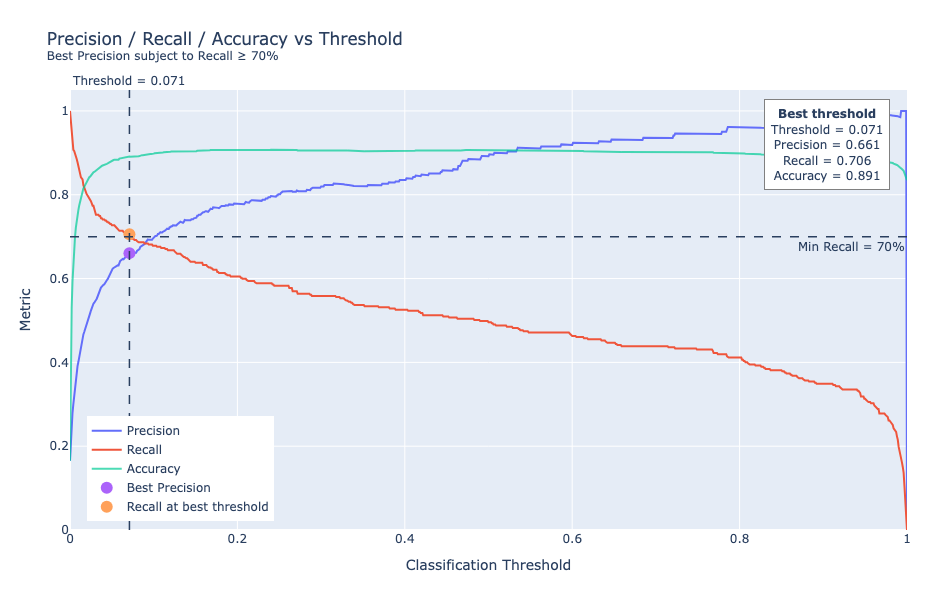

/opt/homebrew/Caskroom/miniconda/base/envs/ultravenv3.10/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [98]:


# ==========================================
# Thresholds
# ==========================================

thresholds = np.linspace(0, 1, 1001)

precisions = []
recalls = []
accuracies = []

for threshold in thresholds:

    y_pred = (
        y_test_proba >= threshold
    ).astype(int)

    precisions.append(
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    recalls.append(
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    accuracies.append(
        accuracy_score(
            y_test,
            y_pred
        )
    )


precisions = np.array(precisions)
recalls = np.array(recalls)
accuracies = np.array(accuracies)


# ==========================================
# Best Precision при Recall >= 0.70
# ==========================================

min_recall = 0.70

valid = recalls >= min_recall

best_idx = np.where(valid)[0][
    np.argmax(precisions[valid])
]

best_threshold = thresholds[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]
best_accuracy = accuracies[best_idx]


print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision:      {best_precision:.4f}")
print(f"Recall:         {best_recall:.4f}")
print(f"Accuracy:       {best_accuracy:.4f}")


# ==========================================
# Plotly
# ==========================================

fig = go.Figure()


# Precision
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=precisions,
        mode="lines",
        name="Precision",
        line=dict(width=2)
    )
)


# Recall
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=recalls,
        mode="lines",
        name="Recall",
        line=dict(width=2)
    )
)


# Accuracy
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=accuracies,
        mode="lines",
        name="Accuracy",
        line=dict(width=2),
        opacity=0.7
    )
)


# ==========================================
# Минимальный Recall
# ==========================================

fig.add_hline(
    y=min_recall,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Min Recall = {min_recall:.0%}",
    annotation_position="bottom right"
)


# ==========================================
# Лучший threshold
# ==========================================

fig.add_vline(
    x=best_threshold,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Threshold = {best_threshold:.3f}",
    annotation_position="top"
)


# ==========================================
# Точки выбранных Precision и Recall
# ==========================================

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_precision],
        mode="markers",
        name="Best Precision",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Precision: {best_precision:.3f}<br>"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_recall],
        mode="markers",
        name="Recall at best threshold",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Recall: {best_recall:.3f}<br>"
            "<extra></extra>"
        )
    )
)


# ==========================================
# Annotation
# ==========================================

fig.add_annotation(
    x=0.98,
    y=0.98,
    xref="paper",
    yref="paper",

    text=(
        f"<b>Best threshold</b><br>"
        f"Threshold = {best_threshold:.3f}<br>"
        f"Precision = {best_precision:.3f}<br>"
        f"Recall = {best_recall:.3f}<br>"
        f"Accuracy = {best_accuracy:.3f}"
    ),

    showarrow=False,

    xanchor="right",
    yanchor="top",

    bgcolor="white",
    bordercolor="gray",
    borderwidth=1,
    borderpad=6
)


# ==========================================
# Layout
# ==========================================

fig.update_layout(
    width=600,
    height=600,

    title=(
        "Precision / Recall / Accuracy vs Threshold"
        "<br>"
        "<sup>Best Precision subject to Recall ≥ 70%</sup>"
    ),

    xaxis_title="Classification Threshold",
    yaxis_title="Metric",

    xaxis=dict(
        range=[0, 1]
    ),

    yaxis=dict(
        range=[0, 1.05]
    ),

    hovermode="x unified",

    legend=dict(
        x=0.02,
        y=0.02,
        xanchor="left",
        yanchor="bottom"
    ),

    margin=dict(
        l=70,
        r=30,
        t=90,
        b=70
    )
)


fig.show()

## Catboost + Optuna

### Split

In [167]:
# Доп. сортировка
train = (
    train
    .sort_values("cookie_created_at")
    .reset_index(drop=True)
)

X = train.drop(
    columns=["target", "cookie_id", "cookie_created_at"]
).copy()

y = train["target"].copy()

split_idx = int(len(train) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train: (8872, 133)
Test: (2219, 133)
Train positive rate: 0.059963931469792606
Test positive rate: 0.1653898152320865


### Fit

In [169]:
cv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    params = {
        "loss_function": "Logloss",
        "iterations": trial.suggest_int("iterations", 300, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 5.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 3.0),
        "random_seed": random_state,
        "cat_features": categorical_features,
        "thread_count": -1,
        "verbose": False,
    }
    

    roc_scores = []
    pr_scores = []

    for train_idx, valid_idx in cv.split(X_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_valid = X_train.iloc[valid_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        if y_fold_valid.nunique() < 2:
            continue

        model = CatBoostClassifier(**params)
        model.fit(X_fold_train, y_fold_train)

        y_pred_proba = model.predict_proba(X_fold_valid)[:, 1]

        roc_scores.append(
            roc_auc_score(y_fold_valid, y_pred_proba)
        )

        pr_scores.append(
            average_precision_score(y_fold_valid, y_pred_proba)
        )

    if len(pr_scores) == 0:
        return 0.0

    mean_roc = np.mean(roc_scores)
    mean_pr = np.mean(pr_scores)

    trial.set_user_attr("roc_auc", mean_roc)
    trial.set_user_attr("pr_auc", mean_pr)

    return mean_pr


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

best_trial = study.best_trial

print(f"Best score: {study.best_value:.4f}")
print(f"ROC AUC CV: {best_trial.user_attrs['roc_auc']:.4f}")
print(f"PR AUC CV: {best_trial.user_attrs['pr_auc']:.4f}")
print("\nBest params:")
print(study.best_params)

[I 2026-09-28 21:57:08,033] A new study created in memory with name: no-name-bb5ea39f-3224-44d5-92ba-56633d7e550e
[I 2026-09-28 21:57:11,054] Trial 15 finished with value: 0.5589442106239968 and parameters: {'iterations': 935, 'learning_rate': 0.026832002012433707, 'depth': 4, 'l2_leaf_reg': 2.241520093095338, 'random_strength': 0.16202365203281408, 'bagging_temperature': 0.7340516641005698}. Best is trial 5 with value: 0.5638396551359209.
--- Logging error ---
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/ultravenv3.10/lib/python3.10/logging/__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "/opt/homebrew/Caskroom/miniconda/base/envs/ultravenv3.10/lib/python3.10/site-packages/ipykernel/iostream.py", line 760, in write
    self._schedule_flush()
  File "/opt/homebrew/Caskroom/miniconda/base/envs/ultravenv3.10/lib/python3.10/site-packages/ipykernel/iostream.py", line 656, in _schedule_flush
    self.pub_thread.schedul

KeyboardInterrupt: 

In [ ]:
final_model = CatBoostClassifier(
    **study.best_params,
    loss_function="Logloss",
    random_seed=random_state,
    thread_count=-1,
    verbose=False
)

final_model.fit(X_train, y_train)

joblib.dump(final_model, "./models/catboost_optuna.pkl")

In [ ]:
y_test_proba = final_model.predict_proba(
    X_test
)[:, 1]

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print(f"Test ROC AUC: {test_roc_auc:.4f}")
print(f"Test PR AUC:  {test_pr_auc:.4f}")

### Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.get_feature_importance(
        type="PredictionValuesChange"
    )
})

top_n = 20

importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .head(top_n)
    .sort_values("importance")
)

fig = px.bar(
    importance,
    x="importance",
    y="feature",
    orientation="h",
    title="CatBoost Feature Importance",
    labels={
        "importance": "Prediction Values Change, %",
        "feature": "Feature"
    }
)

fig.update_layout(
    width=500,
    height=500,
    showlegend=False
)

fig.show()

### Score

In [ ]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(4, 4))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM ROC AUC = {test_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

baseline = y_test.mean()

plt.figure(figsize=(4, 4))

plt.plot(
    recall,
    precision,
    label=f"LightGBM PR AUC = {test_pr_auc:.4f}"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:


# ==========================================
# Thresholds
# ==========================================

thresholds = np.linspace(0, 1, 1001)

precisions = []
recalls = []
accuracies = []

for threshold in thresholds:

    y_pred = (
        y_test_proba >= threshold
    ).astype(int)

    precisions.append(
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    recalls.append(
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    accuracies.append(
        accuracy_score(
            y_test,
            y_pred
        )
    )


precisions = np.array(precisions)
recalls = np.array(recalls)
accuracies = np.array(accuracies)


# ==========================================
# Best Precision при Recall >= 0.70
# ==========================================

min_recall = 0.70

valid = recalls >= min_recall

best_idx = np.where(valid)[0][
    np.argmax(precisions[valid])
]

best_threshold = thresholds[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]
best_accuracy = accuracies[best_idx]


print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision:      {best_precision:.4f}")
print(f"Recall:         {best_recall:.4f}")
print(f"Accuracy:       {best_accuracy:.4f}")


# ==========================================
# Plotly
# ==========================================

fig = go.Figure()


# Precision
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=precisions,
        mode="lines",
        name="Precision",
        line=dict(width=2)
    )
)


# Recall
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=recalls,
        mode="lines",
        name="Recall",
        line=dict(width=2)
    )
)


# Accuracy
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=accuracies,
        mode="lines",
        name="Accuracy",
        line=dict(width=2),
        opacity=0.7
    )
)


# ==========================================
# Минимальный Recall
# ==========================================

fig.add_hline(
    y=min_recall,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Min Recall = {min_recall:.0%}",
    annotation_position="bottom right"
)


# ==========================================
# Лучший threshold
# ==========================================

fig.add_vline(
    x=best_threshold,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Threshold = {best_threshold:.3f}",
    annotation_position="top"
)


# ==========================================
# Точки выбранных Precision и Recall
# ==========================================

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_precision],
        mode="markers",
        name="Best Precision",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Precision: {best_precision:.3f}<br>"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_recall],
        mode="markers",
        name="Recall at best threshold",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Recall: {best_recall:.3f}<br>"
            "<extra></extra>"
        )
    )
)


# ==========================================
# Annotation
# ==========================================

fig.add_annotation(
    x=0.98,
    y=0.98,
    xref="paper",
    yref="paper",

    text=(
        f"<b>Best threshold</b><br>"
        f"Threshold = {best_threshold:.3f}<br>"
        f"Precision = {best_precision:.3f}<br>"
        f"Recall = {best_recall:.3f}<br>"
        f"Accuracy = {best_accuracy:.3f}"
    ),

    showarrow=False,

    xanchor="right",
    yanchor="top",

    bgcolor="white",
    bordercolor="gray",
    borderwidth=1,
    borderpad=6
)


# ==========================================
# Layout
# ==========================================

fig.update_layout(
    width=600,
    height=600,

    title=(
        "Precision / Recall / Accuracy vs Threshold"
        "<br>"
        "<sup>Best Precision subject to Recall ≥ 70%</sup>"
    ),

    xaxis_title="Classification Threshold",
    yaxis_title="Metric",

    xaxis=dict(
        range=[0, 1]
    ),

    yaxis=dict(
        range=[0, 1.05]
    ),

    hovermode="x unified",

    legend=dict(
        x=0.02,
        y=0.02,
        xanchor="left",
        yanchor="bottom"
    ),

    margin=dict(
        l=70,
        r=30,
        t=90,
        b=70
    )
)


fig.show()

## LightGBM + Optuna

### Split

In [ ]:
# Доп. сортировка
train = (
    train
    .sort_values("cookie_created_at")
    .reset_index(drop=True)
)

X = train.drop(
    columns=["target", "cookie_id", "cookie_created_at"]
).copy()

y = train["target"].copy()

split_idx = int(len(train) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

### Fit

In [ ]:
cv = TimeSeriesSplit(
    n_splits=5
)

def objective(trial):
    params = {
        "objective": "binary",

        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),

        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "num_leaves": trial.suggest_int("num_leaves", 7, 63),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),

        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 20.0, log=True),

        "random_state": random_state,
        "n_jobs": -1,
        "verbosity": -1,
    }

    # Time Split CV
    roc_scores = []
    pr_scores = []
    for _, (train_idx, valid_idx) in enumerate(
        cv.split(X_train)
    ):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_valid = X_train.iloc[valid_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        # ROC AUC нельзя посчитать,
        # если в validation только один класс
        if y_fold_valid.nunique() < 2:
            continue

        model = lgb.LGBMClassifier(**params)
        model.fit(X_fold_train, y_fold_train)

        y_pred_proba = model.predict_proba(X_fold_valid)[:, 1]
        roc = roc_auc_score(
            y_fold_valid,
            y_pred_proba
        )
        pr_auc = average_precision_score(
            y_fold_valid,
            y_pred_proba
        )
        roc_scores.append(roc)
        pr_scores.append(pr_auc)

    if len(pr_scores) == 0:
        return 0.0

    mean_roc = np.mean(roc_scores)
    mean_pr = np.mean(pr_scores)

    trial.set_user_attr(
        "roc_auc",
        mean_roc
    )

    trial.set_user_attr(
        "pr_auc",
        mean_pr
    )

    # Используем PR_AUC, чтобы не получить ложнопозитивный ROC AUC
    return mean_pr


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
best_trial = study.best_trial

print(f"Best score: {study.best_value:.4f}")
print(f"ROC AUC CV: {best_trial.user_attrs['roc_auc']:.4f}")
print(f"PR AUC CV: {best_trial.user_attrs['pr_auc']:.4f}")
print("\nBest params:")
print(study.best_params)

In [ ]:
final_model = lgb.LGBMClassifier(
    **study.best_params.copy(),
    objective="binary",
    random_state=random_state,
    n_jobs=-1,
    verbosity=-1
)
final_model.fit(X_train, y_train)

joblib.dump(final_model, "./models/lightGBM_optuna.pkl")

In [ ]:
y_test_proba = final_model.predict_proba(
    X_test
)[:, 1]

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print(f"Test ROC AUC: {test_roc_auc:.4f}")
print(f"Test PR AUC:  {test_pr_auc:.4f}")

### Feature Importance

#### Top

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,

    "split": final_model.booster_.feature_importance(
        importance_type="split"
    ),

    "gain": final_model.booster_.feature_importance(
        importance_type="gain"
    )
})

feature_importance["gain"] = (
    feature_importance["gain"]
    / feature_importance["gain"].sum()
    * 100
)

top_n = 30

# Feature importance по Split
split_importance = (
    feature_importance
    .sort_values("split", ascending=False)
    .head(top_n)
    .sort_values("split")
)

fig_split = px.bar(
    split_importance,
    x="split",
    y="feature",
    orientation="h",
    title="Feature Importance — Split",
    labels={
        "split": "Number of splits",
        "feature": "Feature"
    }
)

fig_split.update_layout(
    width=500,
    height=500,
    showlegend=False
)


fig_split.show()

# Feature importance по GAIN
gain_importance = (
    feature_importance
    .sort_values("gain", ascending=False)
    .head(top_n)
    .sort_values("gain")
)


fig_gain = px.bar(
    gain_importance,
    x="gain",
    y="feature",
    orientation="h",
    title="Feature Importance — Gain",
    labels={
        "gain": "Gain, %",
        "feature": "Feature"
    }
)


fig_gain.update_layout(
    width=500,
    height=500,
    showlegend=False
)


fig_gain.show()

#### Bot

In [ ]:
top_n = 20

# Самые неважные признаки по Split
split_importance = (
    feature_importance
    .sort_values("split", ascending=True)
    .head(top_n)
    .sort_values("split", ascending=False)
)

fig_split = px.bar(
    split_importance,
    x="split",
    y="feature",
    orientation="h",
    title="Least Important Features — Split",
    labels={"split": "Number of splits", "feature": "Feature"}
)

fig_split.update_layout(width=500, height=500, showlegend=False)
fig_split.show()


# Самые неважные признаки по Gain
gain_importance = (
    feature_importance
    .sort_values("gain", ascending=True)
    .head(top_n)
    .sort_values("gain", ascending=False)
)

fig_gain = px.bar(
    gain_importance,
    x="gain",
    y="feature",
    orientation="h",
    title="Least Important Features — Gain",
    labels={"gain": "Gain, %", "feature": "Feature"}
)

fig_gain.update_layout(width=500, height=500, showlegend=False)
fig_gain.show()

### Score

In [ ]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(4, 4))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM ROC AUC = {test_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

baseline = y_test.mean()

plt.figure(figsize=(4, 4))

plt.plot(
    recall,
    precision,
    label=f"LightGBM PR AUC = {test_pr_auc:.4f}"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:


# ==========================================
# Thresholds
# ==========================================

thresholds = np.linspace(0, 1, 1001)

precisions = []
recalls = []
accuracies = []

for threshold in thresholds:

    y_pred = (
        y_test_proba >= threshold
    ).astype(int)

    precisions.append(
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    recalls.append(
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    accuracies.append(
        accuracy_score(
            y_test,
            y_pred
        )
    )


precisions = np.array(precisions)
recalls = np.array(recalls)
accuracies = np.array(accuracies)


# ==========================================
# Best Precision при Recall >= 0.70
# ==========================================

min_recall = 0.70

valid = recalls >= min_recall

best_idx = np.where(valid)[0][
    np.argmax(precisions[valid])
]

best_threshold = thresholds[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]
best_accuracy = accuracies[best_idx]


print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision:      {best_precision:.4f}")
print(f"Recall:         {best_recall:.4f}")
print(f"Accuracy:       {best_accuracy:.4f}")


# ==========================================
# Plotly
# ==========================================

fig = go.Figure()


# Precision
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=precisions,
        mode="lines",
        name="Precision",
        line=dict(width=2)
    )
)


# Recall
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=recalls,
        mode="lines",
        name="Recall",
        line=dict(width=2)
    )
)


# Accuracy
fig.add_trace(
    go.Scatter(
        x=thresholds,
        y=accuracies,
        mode="lines",
        name="Accuracy",
        line=dict(width=2),
        opacity=0.7
    )
)


# ==========================================
# Минимальный Recall
# ==========================================

fig.add_hline(
    y=min_recall,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Min Recall = {min_recall:.0%}",
    annotation_position="bottom right"
)


# ==========================================
# Лучший threshold
# ==========================================

fig.add_vline(
    x=best_threshold,
    line_dash="dash",
    line_width=1.5,
    annotation_text=f"Threshold = {best_threshold:.3f}",
    annotation_position="top"
)


# ==========================================
# Точки выбранных Precision и Recall
# ==========================================

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_precision],
        mode="markers",
        name="Best Precision",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Precision: {best_precision:.3f}<br>"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=[best_threshold],
        y=[best_recall],
        mode="markers",
        name="Recall at best threshold",
        marker=dict(
            size=12
        ),
        hovertemplate=(
            f"Threshold: {best_threshold:.3f}<br>"
            f"Recall: {best_recall:.3f}<br>"
            "<extra></extra>"
        )
    )
)


# ==========================================
# Annotation
# ==========================================

fig.add_annotation(
    x=0.98,
    y=0.98,
    xref="paper",
    yref="paper",

    text=(
        f"<b>Best threshold</b><br>"
        f"Threshold = {best_threshold:.3f}<br>"
        f"Precision = {best_precision:.3f}<br>"
        f"Recall = {best_recall:.3f}<br>"
        f"Accuracy = {best_accuracy:.3f}"
    ),

    showarrow=False,

    xanchor="right",
    yanchor="top",

    bgcolor="white",
    bordercolor="gray",
    borderwidth=1,
    borderpad=6
)


# ==========================================
# Layout
# ==========================================

fig.update_layout(
    width=600,
    height=600,

    title=(
        "Precision / Recall / Accuracy vs Threshold"
        "<br>"
        "<sup>Best Precision subject to Recall ≥ 70%</sup>"
    ),

    xaxis_title="Classification Threshold",
    yaxis_title="Metric",

    xaxis=dict(
        range=[0, 1]
    ),

    yaxis=dict(
        range=[0, 1.05]
    ),

    hovermode="x unified",

    legend=dict(
        x=0.02,
        y=0.02,
        xanchor="left",
        yanchor="bottom"
    ),

    margin=dict(
        l=70,
        r=30,
        t=90,
        b=70
    )
)


fig.show()

# Final


## Read data and best model

In [59]:
train = (
    train
    .sort_values("cookie_created_at")
    .reset_index(drop=True)
)

X = train.drop(
    columns=["target", "cookie_id", "cookie_created_at"]
).copy()

y = train["target"].copy()

split_idx = int(len(train) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

for col in categorical_features:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train: (8872, 133)
Test: (2219, 133)
Train positive rate: 0.059963931469792606
Test positive rate: 0.1653898152320865


## Score

In [60]:
best_model = joblib.load("./models/catboost.pkl")
best_model.fit(X_train, y_train)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

precision_score = precision_at_recall(
    y_test,
    y_test_proba
)

recall_fpr_score = recall_at_fpr(
    y_test,
    y_test_proba
)

print(f"Precision @ Recall >= 0.70: {precision_score:.4f}")
print(f"Recall @ FPR <= 0.01:       {recall_fpr_score:.4f}")

Precision @ Recall >= 0.70: 0.7080
Recall @ FPR <= 0.01:       0.5123


## Submission

In [70]:
submussion_test = (
    test
    .sort_values("cookie_created_at")
    .reset_index(drop=True)
)

submussion_X = submussion_test.drop(columns=["cookie_id", "cookie_created_at"])

for col in categorical_features:
    submussion_X[col] = submussion_X[col].astype("category")


best_model = joblib.load("./models/catboost.pkl")

sub = pd.DataFrame({
    'cookie_id': submussion_test["cookie_id"],
    'score': best_model.predict_proba(submussion_X)[:, 1],
})
assert len(sub) == len(test) and sub.score.between(0, 1).all()
sub.to_csv('submission.csv', index=False)
sub.head()

,cookie_id,score
0,ck_8f346b72fb40bf14,0.011086
1,ck_837cc7fd48453a01,0.016263
2,ck_826a27ff7555192e,0.020752
3,ck_d86ccf148c06c8c8,0.052315
4,ck_2df5a9fc87553eb1,0.006416
